# Ghigliottina — Local models analysis

Analyzes the 3 sheets `T_0.0`/`T_0.3`/`T_0.7` (local models only — commercial
models have a different collection design, single run and uncontrolled
parameters, and must be analyzed separately, not in this notebook).

Re-run this notebook every time you add new data (another session,
other models, a more complete manual review) — no cell saves an
intermediate state, it always starts over from the Excel files.


In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 40)

## Configuration

`RESULT_FILES` accepts multiple files: useful if you still have separate
sessions (e.g. Session 1 in one file and a smoke test of new models in
another) before consolidating them into a single `ghigliottina_results.xlsx`.
If a duplicate item (same model, same prompt, same temperature)
appears in more than one file, the first occurrence is kept and a warning
is printed — it doesn't silently disappear.


In [2]:
RESULT_FILES = [r"D:\guillotine\guillotine\source\complete_ghigliottina_results.xlsx"]

RUN_SHEETS = ["T_0.0", "T_0.3", "T_0.7"]
EXPECTED_PROMPTS_PER_TEMP = 30

# Same list as config.py - if you update it there, copy it here too.
# it has only been updated here; the chart should show more than 30 models, but not all of them are there
REASONING_MODEL_MARKERS = [ "aion-labs/aion-3.0-mini",
                            "arcee-ai/trinity-large-thinking",
                            "bytedance-seed/seed-1.6-flash",
                            "bytedance-seed/seed-2-1-turbo",
                            "deepseek/deepseek-v3.2",
                            "deepseek/deepseek-v4-flash-0731",
                            "inclusionai/ling-3.0-flash",
                            "inclusionai/ring-2.6-1t",
                            "lfm2.5:8b",
                            "moonshotai/kimi-k2.5",
                            "nex-agi/nex-n2-mini",
                            "nex-agi/nex-n2-pro",
                            "nvidia/nemotron-3-ultra-550b-a55b",
                            "nvidia/nemotron-3.5-lightning:free",
                            "nvidia/nemotron-nano-9b-v2:free",
                            "qwen/qwen3-235b-a22b-thinking-2507",
                            "qwen/qwen3-32b",
                            "qwen/qwen3-next-80b-a3b-thinking",
                            "qwen/qwen3.7-flash",
                            "qwen/qwen3.7-plus",
                            "stepfun/step-3.5-flash",
                            "stepfun/step-3.7-flash",
                            "tencent/hunyuan-a13b-instruct",
                            "tencent/hy3",
                            "thinkingmachines/inkling-small",
                            "xiaomi/mimo-v2.5",
                            "xiaomi/mimo-v2.5-pro",
                            "z-ai/glm-4.5-air",
                            "z-ai/glm-4.6v",
                            "z-ai/glm-4.7",
                            "z-ai/glm-4.7-flash",
                            "z-ai/glm-5.2:free",
                            "deepseek-r1",
                            "qwq",
                            "gpt-oss",
                            "qwen3.5",
                            "gemma4:12b",
                            "qwen3:14b",
                            "starcoder2:15b-instruct"]

# Approximate size in billions of parameters, where it cannot be derived from the tag.
MANUAL_SIZE_OVERRIDES_B = ({
    "nemotron-3-nano:4b": 4.0,
    "gemma4:e4b": 4.0,  # effective ~4B (as stated by the vendor)
    "nous-hermes2:latest": 10.7,  # Nous-Hermes-2-Solar
    "phi3.5:latest": 3.8,  # Phi-3.5-mini
    "phi3:mini": 3.8,  # Phi-3-mini
})

# Verified against official model cards/technical reports (August 2026).
# Format: {"total": ..., "active": ...} - active = total for dense models.
OPENROUTER_VERIFIED_PARAMS_B = {
    "deepseek/deepseek-r1-0528":              {"total": 671.0, "active": 37.0},
    "deepseek/deepseek-v3.2":                 {"total": 671.0, "active": 37.0},  # same architecture as V3, not explicitly confirmed for this version
    "moonshotai/kimi-k2.5":                   {"total": 1000.0, "active": 32.0},
    "inclusionai/ring-2.6-1t":                {"total": 1000.0, "active": None},  # "1t" explicit in the name, active count not found
    "inclusionai/ling-2.6-1t":                {"total": 1000.0, "active": None},
    "z-ai/glm-4.5-air":                       {"total": 106.0, "active": 12.0},
    "thinkingmachines/inkling-small":         {"total": 276.0, "active": 12.0},
    "meta-llama/llama-4-maverick":            {"total": 400.0, "active": 17.0},
    "meta-llama/llama-4-scout":               {"total": 109.0, "active": 17.0},
    "cohere/command-r-plus-08-2024":          {"total": 104.0, "active": 104.0},
    "cohere/command-r-08-2024":               {"total": 35.0, "active": 35.0},
}

# Searched for but with no publicly available declared count - not
# guessed, left out. Most of the OpenRouter catalog does not
# declare parameters (verified in a previous session: about 29 out of
# 417 total models do) - this isn't a research gap, it's a
# structural limit of what vendors publish:
# z-ai/glm-5.2:free, z-ai/glm-4.7, z-ai/glm-4.6v, z-ai/glm-4.7-flash,
# stepfun/step-3.5-flash, stepfun/step-3.7-flash,
# bytedance-seed/seed-2-1-turbo, bytedance-seed/seed-1.6-flash,
# xiaomi/mimo-v2.5, xiaomi/mimo-v2.5-pro,
# qwen/qwen3.7-plus, qwen/qwen3.7-flash,
# deepseek/deepseek-v4-flash-0731,
# nex-agi/nex-n2-pro, nex-agi/nex-n2-mini,
# tencent/hy3, aion-labs/aion-3.0-mini,
# nvidia/nemotron-3.5-lightning:free,
# arcee-ai/trinity-large-thinking,
# mistralai/mistral-medium-3.1, mistralai/mistral-saba,
# upstage/solar-pro4, inclusionai/ling-3.0-flash, inclusionai/ling-2.6-flash,
# amazon/nova-micro-v1, amazon/nova-2-lite-v1,
# openai/gpt-3.5-turbo, openai/gpt-4o-mini,  # OpenAI never declares parameters
# ibm-granite/granite-4.0-h-micro


def parse_size_billion(model_tag: str) -> float | None:
    """Extracts the size in billions of parameters from the tag (e.g. '7b', '1.6b', '345m')."""
    if model_tag in MANUAL_SIZE_OVERRIDES_B:
        return MANUAL_SIZE_OVERRIDES_B[model_tag]
    m = re.search(r"(\d+(?:\.\d+)?)\s*b\b", model_tag.lower())
    if m:
        return float(m.group(1))
    m = re.search(r"(\d+(?:\.\d+)?)\s*m\b", model_tag.lower())
    if m:
        return float(m.group(1)) / 1000.0
    return None


def is_reasoning_model(model_name: str) -> bool:
    return any(marker in model_name.lower() for marker in REASONING_MODEL_MARKERS)

## Data loading

Reads the 3 sheets from each file, adds the `temperature` column
(derived from the sheet name), and handles compatibility with files
written before `duration_s`/`status`/`is_clue_echo` existed in the
schema (fills them with a neutral default instead of failing).


In [3]:
def load_results(paths: list[str]) -> pd.DataFrame:
    frames = []
    for path in paths:
        path = Path(path)
        if not path.exists():
            warnings.warn(f"File not found, skipped: {path}")
            continue
        for sheet in RUN_SHEETS:
            df = pd.read_excel(path, sheet_name=sheet, engine="openpyxl")
            if df.empty:
                continue
            df["temperature"] = float(sheet.replace("T_", ""))
            df["source_file"] = path.name
            frames.append(df)

    if not frames:
        raise ValueError("No data loaded - check RESULT_FILES")

    data = pd.concat(frames, ignore_index=True)

    for col, default in [("status", "ok"), ("is_clue_echo", 0), ("is_first_call", 0), ("duration_s", np.nan)]:
        if col not in data.columns:
            data[col] = default
    data["status"] = data["status"].fillna("ok")

    dup_mask = data.duplicated(subset=["model_name", "prompt_id", "temperature"], keep="first")
    if dup_mask.any():
        dups = data.loc[dup_mask, ["model_name", "prompt_id", "temperature", "source_file"]]
        warnings.warn(
            f"{dup_mask.sum()} duplicate rows on (model, prompt, temperature) - "
            f"first occurrence kept. Example:\n{dups.head()}"
        )
        data = data.loc[~dup_mask].copy()

    data["is_reasoning_model"] = data["model_name"].apply(is_reasoning_model)
    return data


data = load_results(RESULT_FILES)
print(f"Total rows loaded: {len(data)}")
print(f"Models: {data['model_name'].nunique()}")
data.head()

Total rows loaded: 9908
Models: 111


C:\Users\PC\AppData\Local\Temp\ipykernel_16840\3135563216.py:29: UserWarning: 270 duplicate rows on (model, prompt, temperature) - first occurrence kept. Example:
                         model_name  prompt_id  temperature  \
849  Hudson/gpt2-instruct:345m-q8_0  guillo_01          0.0   
851  Hudson/gpt2-instruct:345m-q8_0  guillo_02          0.0   
853  Hudson/gpt2-instruct:345m-q8_0  guillo_03          0.0   
855  Hudson/gpt2-instruct:345m-q8_0  guillo_04          0.0   
857  Hudson/gpt2-instruct:345m-q8_0  guillo_05          0.0   

                            source_file  
849  complete_ghigliottina_results.xlsx  
851  complete_ghigliottina_results.xlsx  
853  complete_ghigliottina_results.xlsx  
855  complete_ghigliottina_results.xlsx  
857  complete_ghigliottina_results.xlsx  
  warnings.warn(


,model_name,prompt_id,word1,word2,word3,word4,word5,expected_solution,raw_response,predicted_word,...,synonym_manual,coherence_manual,timestamp,difficulty_note,duration_s,is_first_call,status,temperature,source_file,is_reasoning_model
0,aion-labs/aion-3.0-mini,guillo_01,gluteus,adjustable,sit,office,kitchen,chair,<think>I must not include any extraneous text....,CHAIR,...,0,0,2026-08-26 20:17:42,easy,11.6,0,ok,0.0,complete_ghigliottina_results.xlsx,True
1,aion-labs/aion-3.0-mini,guillo_02,highway,wheel,transport,fuel,insurance,car,<think>I must not include any ethical consider...,CAR,...,0,0,2026-08-26 20:17:48,easy,5.4,0,ok,0.0,complete_ghigliottina_results.xlsx,True
2,aion-labs/aion-3.0-mini,guillo_03,Washington,skyscraper,sewer,courthouse,shop,city,<think>I must not include any additional text ...,BUILDING,...,0,0,2026-08-26 20:24:00,medium,370.7,0,ok,0.0,complete_ghigliottina_results.xlsx,True
3,aion-labs/aion-3.0-mini,guillo_04,Pascal,inch,stress,cloud,blood,pressure,<think>I must not include any ethical consider...,PRESSURE,...,0,0,2026-08-26 20:30:50,medium,409.8,0,ok,0.0,complete_ghigliottina_results.xlsx,True
4,aion-labs/aion-3.0-mini,guillo_05,moon,speed,lamp,hope,visible,light,<think>I must not include any extraneous text ...,LIGHT,...,0,0,2026-08-26 20:30:58,medium,6.9,0,ok,0.0,complete_ghigliottina_results.xlsx,True


## Coverage check

Before trusting any chart below: how many models actually have all
90 expected rows (30 prompts × 3 temperatures)? And how many
timeouts per model — a timeout is not a randomly missing data point, it's
"did not respond within the time limit," and should be looked at
alongside accuracy, not hidden.


In [4]:
coverage = data.groupby("model_name").size().rename("total_rows")
expected = EXPECTED_PROMPTS_PER_TEMP * len(RUN_SHEETS)
incomplete = coverage[coverage < expected]

print(f"Expected coverage per model: {expected} rows")
if len(incomplete):
    print(f"\nModels with incomplete coverage ({len(incomplete)}):")
    print(incomplete)
else:
    print("Complete coverage across all models.")

status_counts = data.groupby(["model_name", "status"]).size().unstack(fill_value=0)
status_counts

Expected coverage per model: 90 rows

Models with incomplete coverage (1):
model_name
arcee-ai/virtuoso-large    8
Name: total_rows, dtype: int64


status,error,ok,timeout
model_name,,,
Hudson/gpt2-instruct:345m-q8_0,0,90,0
aion-labs/aion-3.0-mini,0,90,0
allenai/olmo-3-32b-think,90,0,0
amazon/nova-2-lite-v1,0,90,0
amazon/nova-micro-v1,0,90,0
...,...,...,...
z-ai/glm-4.6v,0,90,0
z-ai/glm-4.7,2,88,0
z-ai/glm-4.7-flash,0,90,0


## RQ1 / RQ2 — Accuracy leaderboard

`exact_match`, `same_root`, `is_similar_lev` are the three automatic
metrics; `is_clue_echo` and `format_compliant` are not accuracy in
themselves but help interpret it (a model with low `exact_match` but
also high `is_clue_echo` is failing differently than one with low
`is_clue_echo`). From here on we work only on `status="ok"` rows —
timeouts have no response to evaluate.


In [5]:
from statsmodels.stats.proportion import proportion_confint

ok_data = data[data["status"] == "ok"].copy()

leaderboard = ok_data.groupby("model_name").agg(
    n=("exact_match", "size"),
    exact_match=("exact_match", "mean"),
    same_root=("same_root", "mean"),
    is_similar_lev=("is_similar_lev", "mean"),
    format_compliant=("format_compliant", "mean"),
    is_clue_echo=("is_clue_echo", "mean"),
    levenshtein_mean=("levenshtein_normalized", "mean"),
).sort_values("exact_match", ascending=False)

successes = (leaderboard["exact_match"] * leaderboard["n"]).round().astype(int)
leaderboard["ci_low"], leaderboard["ci_high"] = proportion_confint(
    successes, leaderboard["n"], method="wilson"
)

top10 = leaderboard.head(20)
top10.round(3)


,n,exact_match,same_root,is_similar_lev,format_compliant,is_clue_echo,levenshtein_mean,ci_low,ci_high
model_name,,,,,,,,,
z-ai/glm-5.2:free,4,0.750,0.750,0.750,0.750,0.000,0.250,0.301,0.954
stepfun/step-3.5-flash,90,0.711,0.778,0.778,0.978,0.000,0.218,0.610,0.795
bytedance-seed/seed-2-1-turbo,90,0.678,0.744,0.744,1.000,0.000,0.235,0.576,0.765
nvidia/nemotron-3-ultra-550b-a55b,90,0.678,0.744,0.744,0.922,0.000,0.243,0.576,0.765
moonshotai/kimi-k2.5,89,0.663,0.730,0.730,0.944,0.000,0.247,0.560,0.753
xiaomi/mimo-v2.5-pro,90,0.656,0.722,0.733,1.000,0.000,0.251,0.553,0.746
qwen/qwen3.7-plus,89,0.629,0.697,0.697,0.888,0.000,0.279,0.525,0.722
olmo-3.1:32b,58,0.621,0.690,0.690,1.000,0.000,0.280,0.492,0.734
z-ai/glm-4.7,88,0.614,0.659,0.659,0.830,0.000,0.319,0.509,0.709


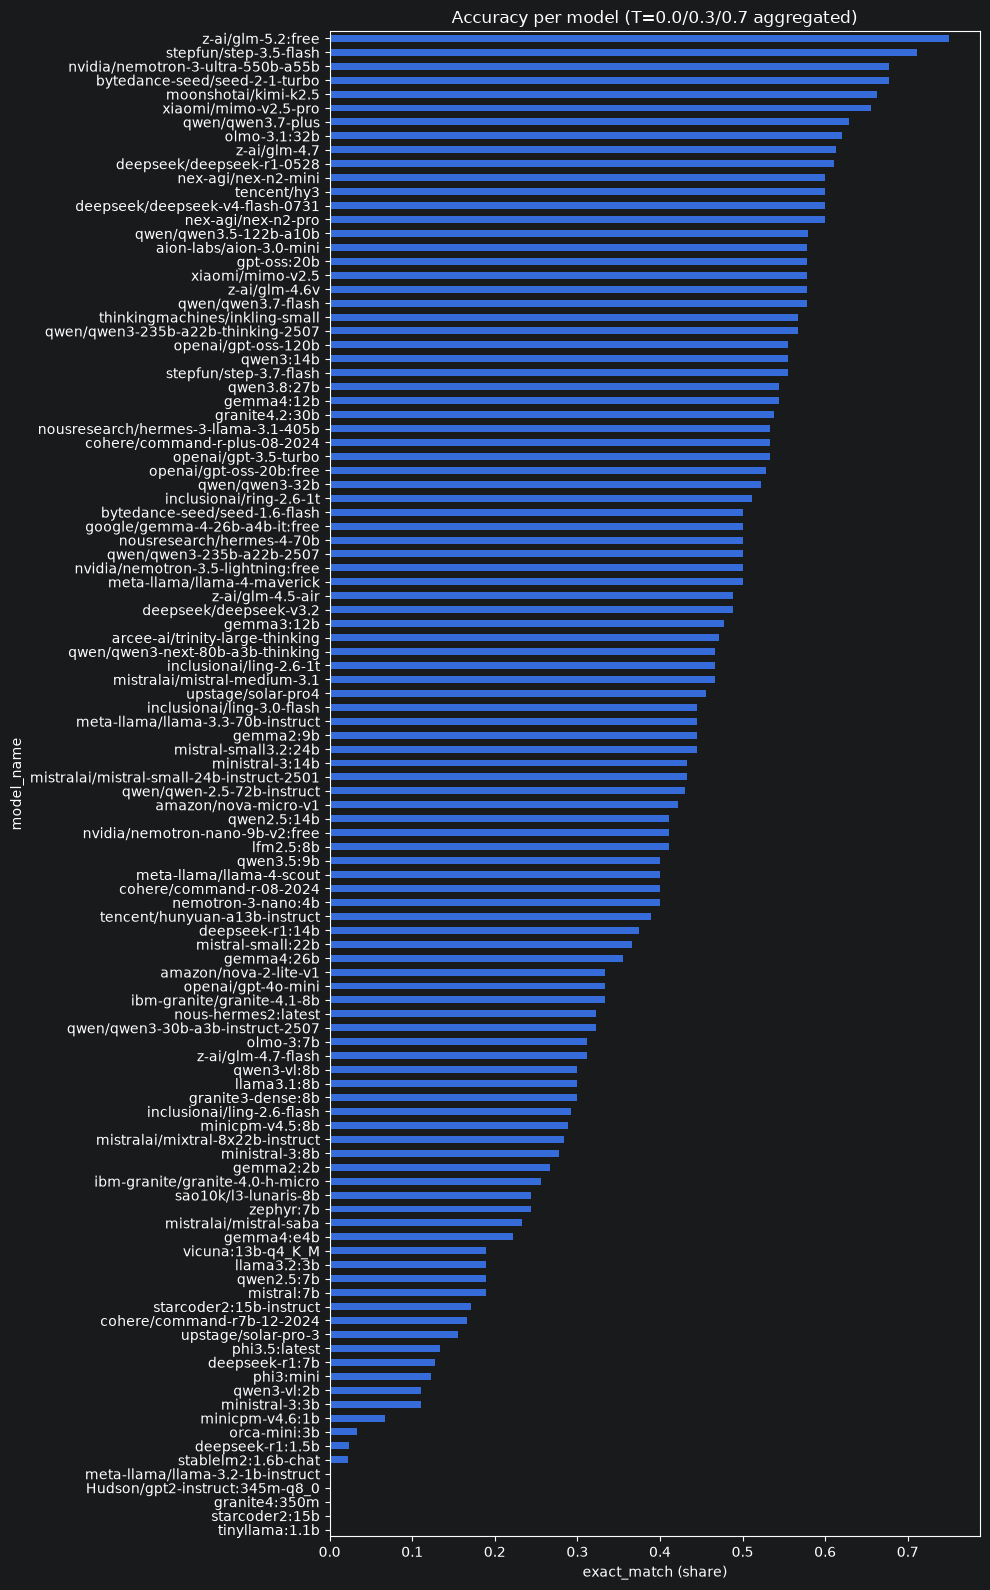

In [6]:
fig, ax = plt.subplots(figsize=(10, 16))
leaderboard["exact_match"].sort_values().plot.barh(ax=ax)
ax.set_xlabel("exact_match (share)")
ax.set_title("Accuracy per model (T=0.0/0.3/0.7 aggregated)")
plt.tight_layout()
plt.show()

## RQ3 — Synonyms and coherence (manual review)

You fill in these two columns by hand, so the first thing to check
below is **how complete the review is**, not the final rate — a rate
computed on 20% of reviewed rows is not yet a number to report in the
whitepaper.


In [7]:
for col in ["synonym_manual", "coherence_manual"]:
    reviewed = ok_data[col].notna().sum()
    total = len(ok_data)
    print(f"{col}: {reviewed}/{total} rows evaluated ({100*reviewed/total:.0f}%)")

    if reviewed:
        reviewed_data = ok_data[ok_data[col].notna()]
        rate = reviewed_data.groupby("model_name")[col].mean().sort_values(ascending=False)
        print(f"Rate on the rows evaluated so far, top 5:\n{rate.head()}\n")

synonym_manual: 9380/9380 rows evaluated (100%)
Rate on the rows evaluated so far, top 5:
model_name
gemma2:9b             0.144444
minicpm-v4.5:8b       0.133333
gemma3:12b            0.133333
gemma4:e4b            0.133333
nemotron-3-nano:4b    0.122222
Name: synonym_manual, dtype: float64

coherence_manual: 9380/9380 rows evaluated (100%)
Rate on the rows evaluated so far, top 5:
model_name
gemma3:12b                         0.233333
ibm-granite/granite-4.0-h-micro    0.211111
minicpm-v4.5:8b                    0.211111
gemma4:e4b                         0.200000
sao10k/l3-lunaris-8b               0.177778
Name: coherence_manual, dtype: float64



## RQ4 — Temperature sensitivity (local models only)

By construction, this section only makes sense here — commercial
models have no temperature axis to position themselves on (single
run, uncontrolled parameters).


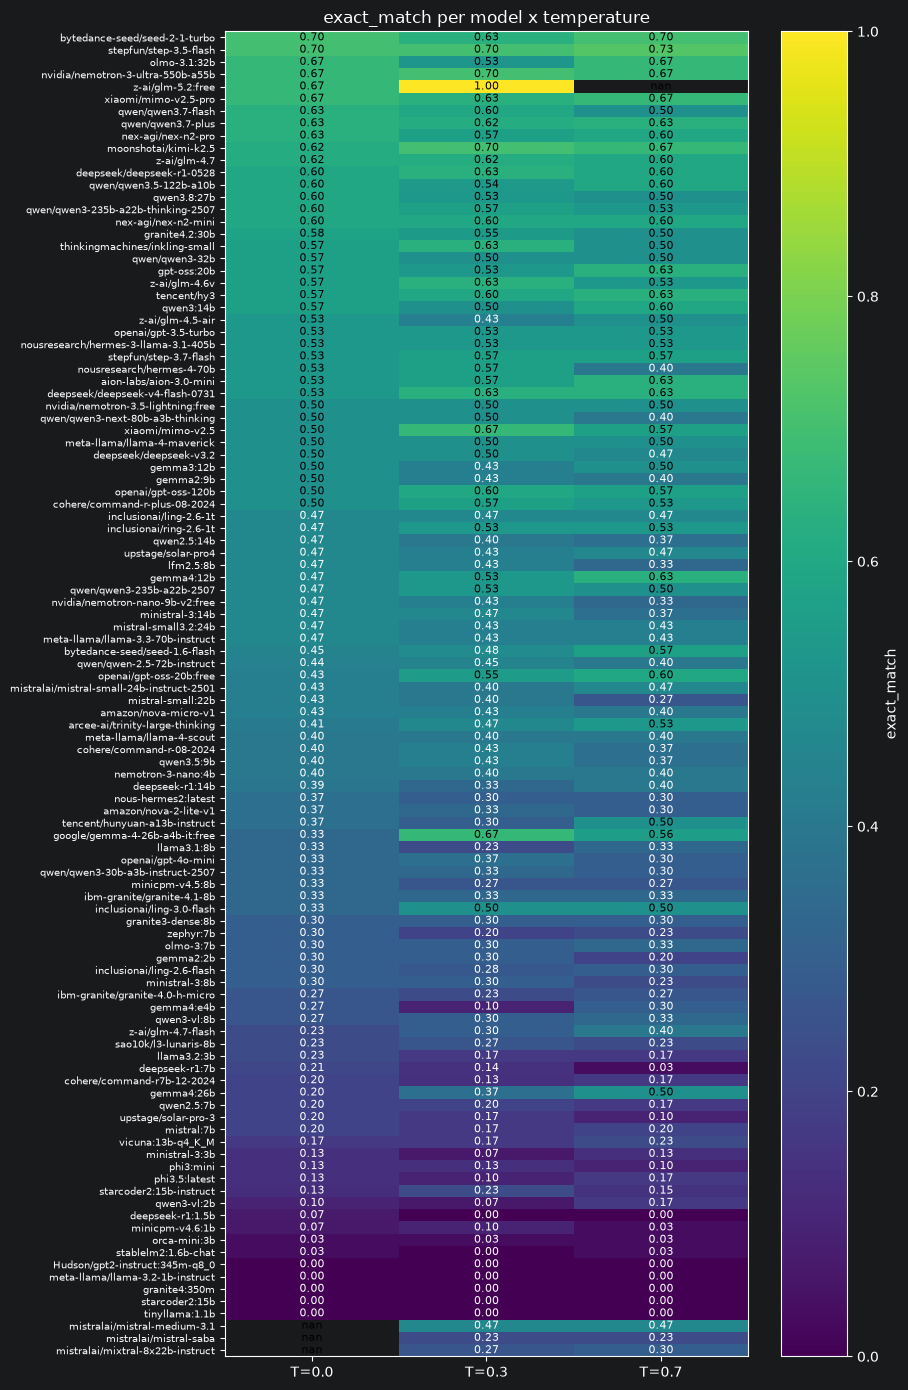

In [8]:
temp_pivot = ok_data.pivot_table(
    index="model_name", columns="temperature", values="exact_match", aggfunc="mean"
).sort_values(0.0, ascending=False)

fig, ax = plt.subplots(figsize=(9, 14))
im = ax.imshow(temp_pivot.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(temp_pivot.columns)))
ax.set_xticklabels([f"T={t}" for t in temp_pivot.columns])
ax.set_yticks(range(len(temp_pivot.index)))
ax.set_yticklabels(temp_pivot.index, fontsize=7)
ax.set_title("exact_match per model x temperature")

for i in range(len(temp_pivot.index)):
    for j in range(len(temp_pivot.columns)):
        val = temp_pivot.iloc[i, j]
        text_color = "white" if val < 0.5 else "black"
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color=text_color, fontsize=8
        )

fig.colorbar(im, ax=ax, label="exact_match")
plt.tight_layout()
plt.show()

In [9]:
temp_range = (temp_pivot.max(axis=1) - temp_pivot.min(axis=1)).sort_values(ascending=False)
print("Models most sensitive to temperature (max-min accuracy across T):")
temp_range.head(8).round(3)

Models most sensitive to temperature (max-min accuracy across T):


model_name
z-ai/glm-5.2:free                 0.333
google/gemma-4-26b-a4b-it:free    0.333
gemma4:26b                        0.300
tencent/hunyuan-a13b-instruct     0.200
gemma4:e4b                        0.200
deepseek-r1:7b                    0.181
z-ai/glm-4.7-flash                0.167
mistral-small:22b                 0.167
dtype: float64

## Generation times: reasoning vs non-reasoning

Always excludes `is_first_call=1` (that row includes loading the
model into VRAM, not pure generation time — see the notes on the
experimental design). The boxplot color follows
`REASONING_MODEL_MARKERS`: if you add a new model that behaves like a
reasoning model but isn't in the list, the boxplot still shows it (in
the "wrong" color) — it's a way to notice it.


In [10]:
timing_data = ok_data[(ok_data["is_first_call"] != 1) & ok_data["duration_s"].notna()]

timing_stats = timing_data.groupby(["model_name", "is_reasoning_model"])["duration_s"].agg(
    ["mean", "std", "count"]
).sort_values("std", ascending=False)
timing_stats.round(1)

,,mean,std,count
model_name,is_reasoning_model,,,
z-ai/glm-4.7,True,397.8,820.2,88
deepseek/deepseek-v4-flash-0731,True,214.4,706.5,90
moonshotai/kimi-k2.5,True,280.5,550.9,89
openai/gpt-oss-20b:free,True,310.3,503.3,89
z-ai/glm-4.7-flash,True,295.9,393.9,90
...,...,...,...,...
gemma2:9b,False,2.3,0.1,89
ministral-3:8b,False,2.2,0.1,89
gemma2:2b,False,2.3,0.1,89


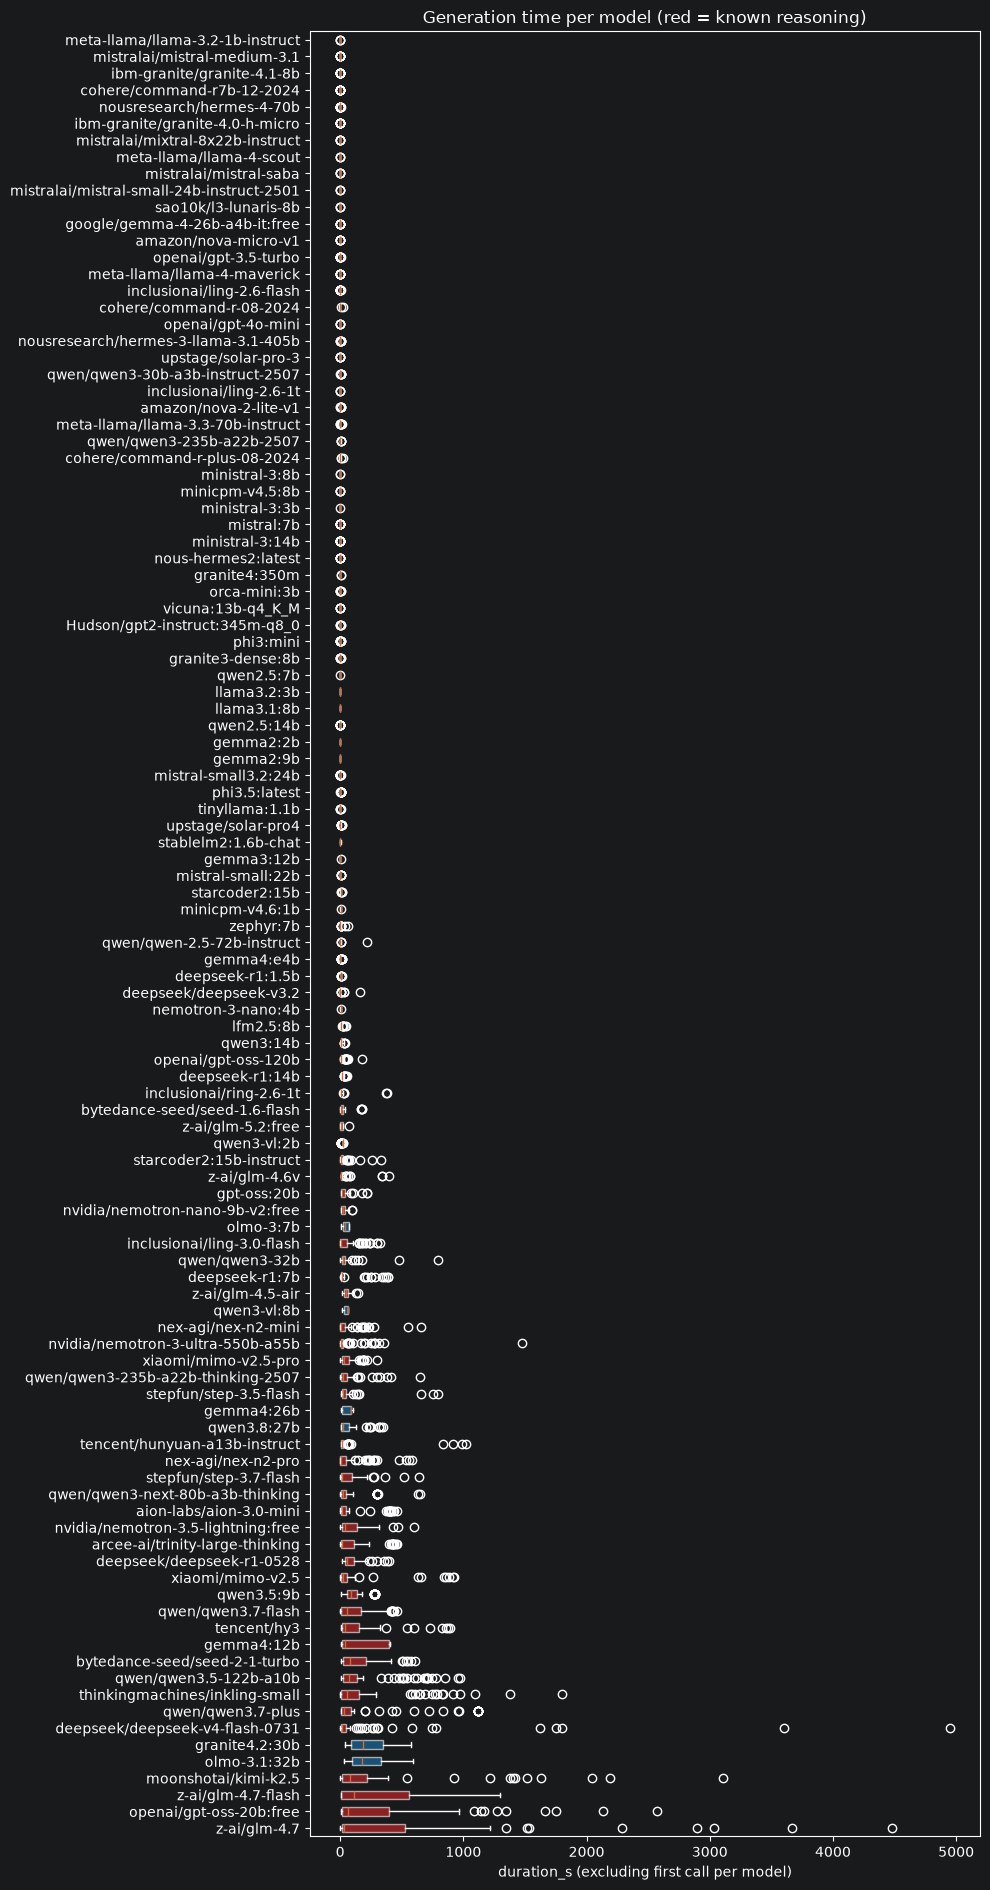

In [11]:
order = timing_data.groupby("model_name")["duration_s"].mean().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 19))
box_data = [timing_data[timing_data["model_name"] == m]["duration_s"].values for m in order]
colors = ["#d62728" if is_reasoning_model(m) else "#1f77b4" for m in order]
bp = ax.boxplot(box_data, orientation="horizontal", tick_labels=list(order), patch_artist=True, showfliers=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_xlabel("duration_s (excluding first call per model)")
ax.set_title("Generation time per model (red = known reasoning)")
plt.tight_layout()
plt.show()

## RQ5 — Model size vs accuracy

Only local models declare parameters in the tag (commercial ones
don't — which is why RQ5 in the strict sense can only be verified
here, as we already established). Tags without a recognizable size
are flagged and excluded from the chart, not guessed at random.


Models with no size derivable from the tag (41), excluded from the chart:
['z-ai/glm-5.2:free', 'stepfun/step-3.5-flash', 'bytedance-seed/seed-2-1-turbo', 'moonshotai/kimi-k2.5', 'xiaomi/mimo-v2.5-pro', 'qwen/qwen3.7-plus', 'z-ai/glm-4.7', 'deepseek/deepseek-r1-0528', 'deepseek/deepseek-v4-flash-0731', 'nex-agi/nex-n2-pro', 'nex-agi/nex-n2-mini', 'tencent/hy3', 'qwen/qwen3.7-flash', 'xiaomi/mimo-v2.5', 'z-ai/glm-4.6v', 'aion-labs/aion-3.0-mini', 'thinkingmachines/inkling-small', 'stepfun/step-3.7-flash', 'openai/gpt-3.5-turbo', 'cohere/command-r-plus-08-2024', 'inclusionai/ring-2.6-1t', 'nvidia/nemotron-3.5-lightning:free', 'meta-llama/llama-4-maverick', 'bytedance-seed/seed-1.6-flash', 'deepseek/deepseek-v3.2', 'z-ai/glm-4.5-air', 'arcee-ai/trinity-large-thinking', 'inclusionai/ling-2.6-1t', 'mistralai/mistral-medium-3.1', 'upstage/solar-pro4', 'inclusionai/ling-3.0-flash', 'amazon/nova-micro-v1', 'cohere/command-r-08-2024', 'meta-llama/llama-4-scout', 'amazon/nova-2-lite-v1', 'openai

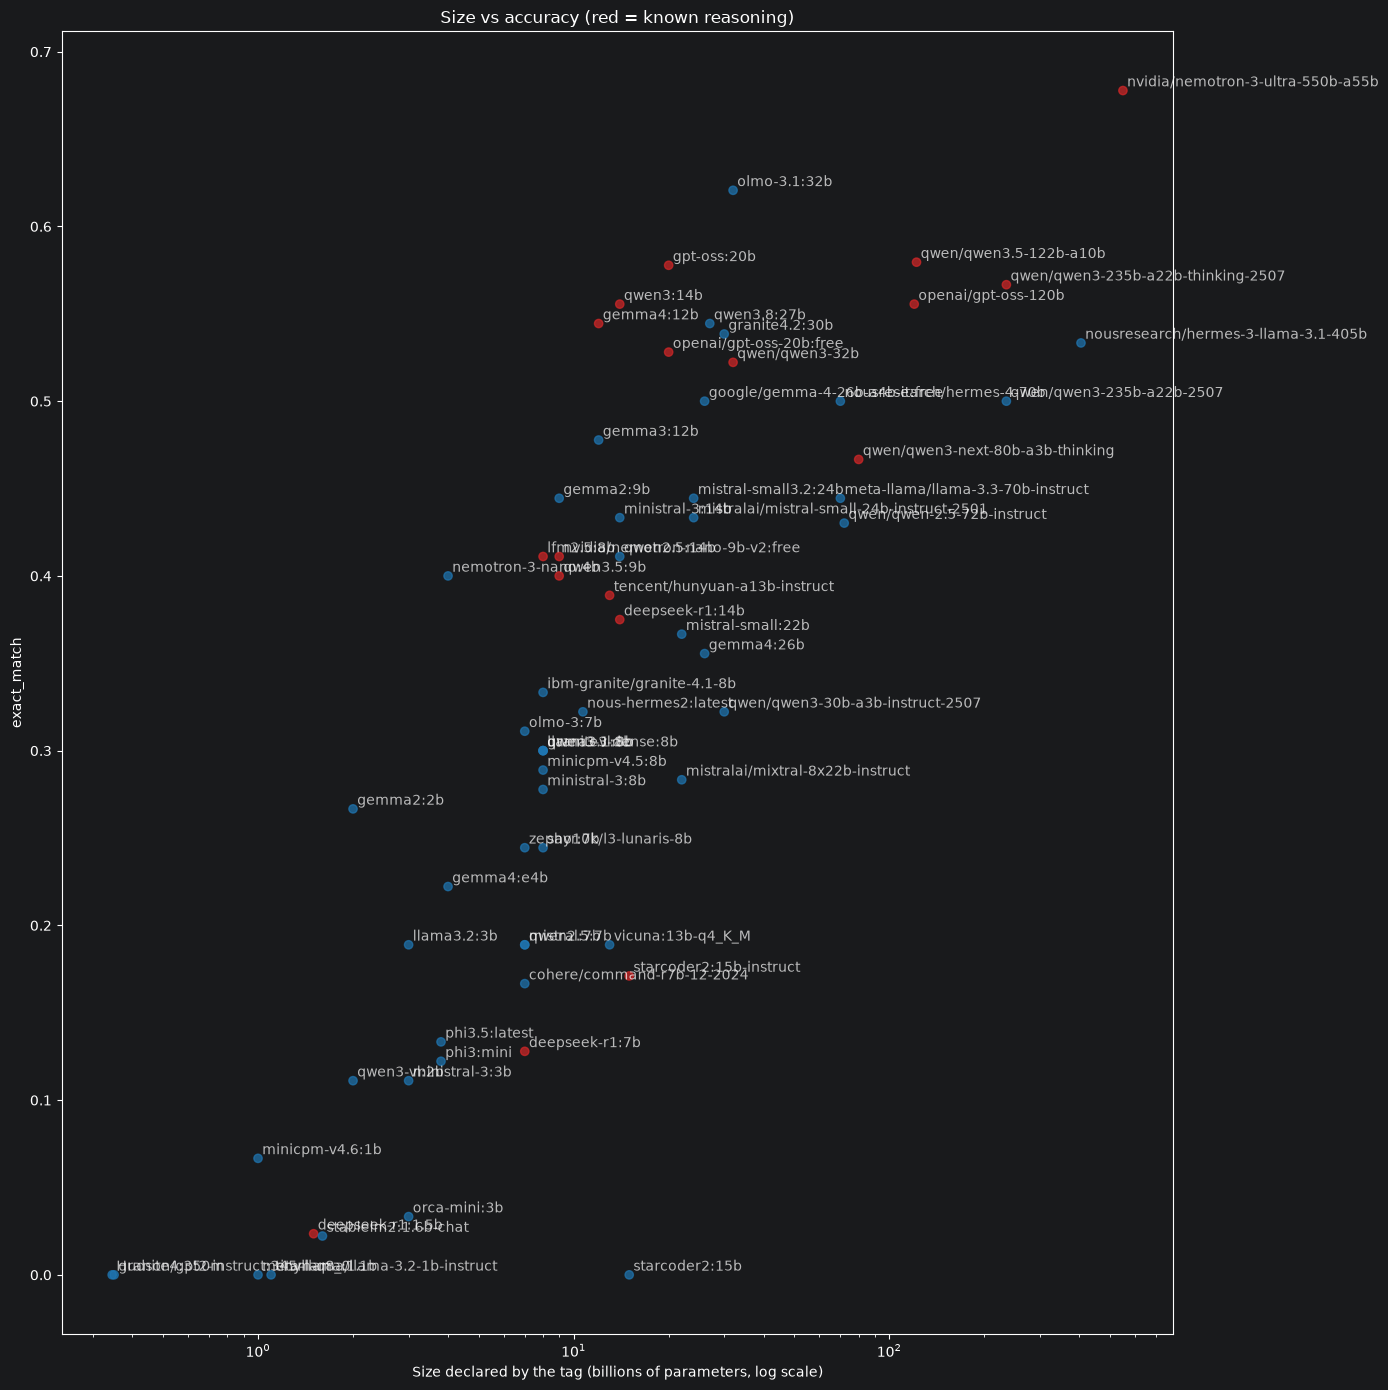

In [12]:
size_df = leaderboard.copy()
size_df["size_b"] = [parse_size_billion(m) for m in size_df.index]

unresolved = size_df[size_df["size_b"].isna()]
if len(unresolved):
    print(f"Models with no size derivable from the tag ({len(unresolved)}), excluded from the chart:")
    print(list(unresolved.index))
    print("Add them to MANUAL_SIZE_OVERRIDES_B if you want to include them.\n")

size_df = size_df.dropna(subset=["size_b"])

fig, ax = plt.subplots(figsize=(14, 14))
colors = ["#d62728" if is_reasoning_model(m) else "#1f77b4" for m in size_df.index]
ax.scatter(size_df["size_b"], size_df["exact_match"], c=colors, alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel("Size declared by the tag (billions of parameters, log scale)")
ax.set_ylabel("exact_match")
ax.set_title("Size vs accuracy (red = known reasoning)")
for m, row in size_df.iterrows():
    ax.annotate(m, (row["size_b"], row["exact_match"]), fontsize=10, alpha=0.7,
                xytext=(3, 3), textcoords="offset points")
plt.tight_layout()
plt.show()

In [13]:
corr = size_df["size_b"].corr(size_df["exact_match"], method="spearman")
print(f"Spearman correlation size/exact_match (all): {corr:.3f}")

corr_non_reasoning = size_df[~size_df.index.map(is_reasoning_model)]
corr2 = corr_non_reasoning["size_b"].corr(corr_non_reasoning["exact_match"], method="spearman")
print(f"Same correlation, non-reasoning models only: {corr2:.3f}")
print("\nSpearman rather than Pearson because we don't care about linearity, only whether")
print("larger size and accuracy ranking tend to move together.")

Spearman correlation size/exact_match (all): 0.827
Same correlation, non-reasoning models only: 0.842

Spearman rather than Pearson because we don't care about linearity, only whether
larger size and accuracy ranking tend to move together.


## Clue-echo as a capability-floor indicator

Share of responses identical (case-insensitive) to one of the 5 given
clues — the model didn't find the connecting word, it repeated an
input clue. It's the cleanest signal of "this model cannot do the
task," more direct than a simply low `exact_match`.


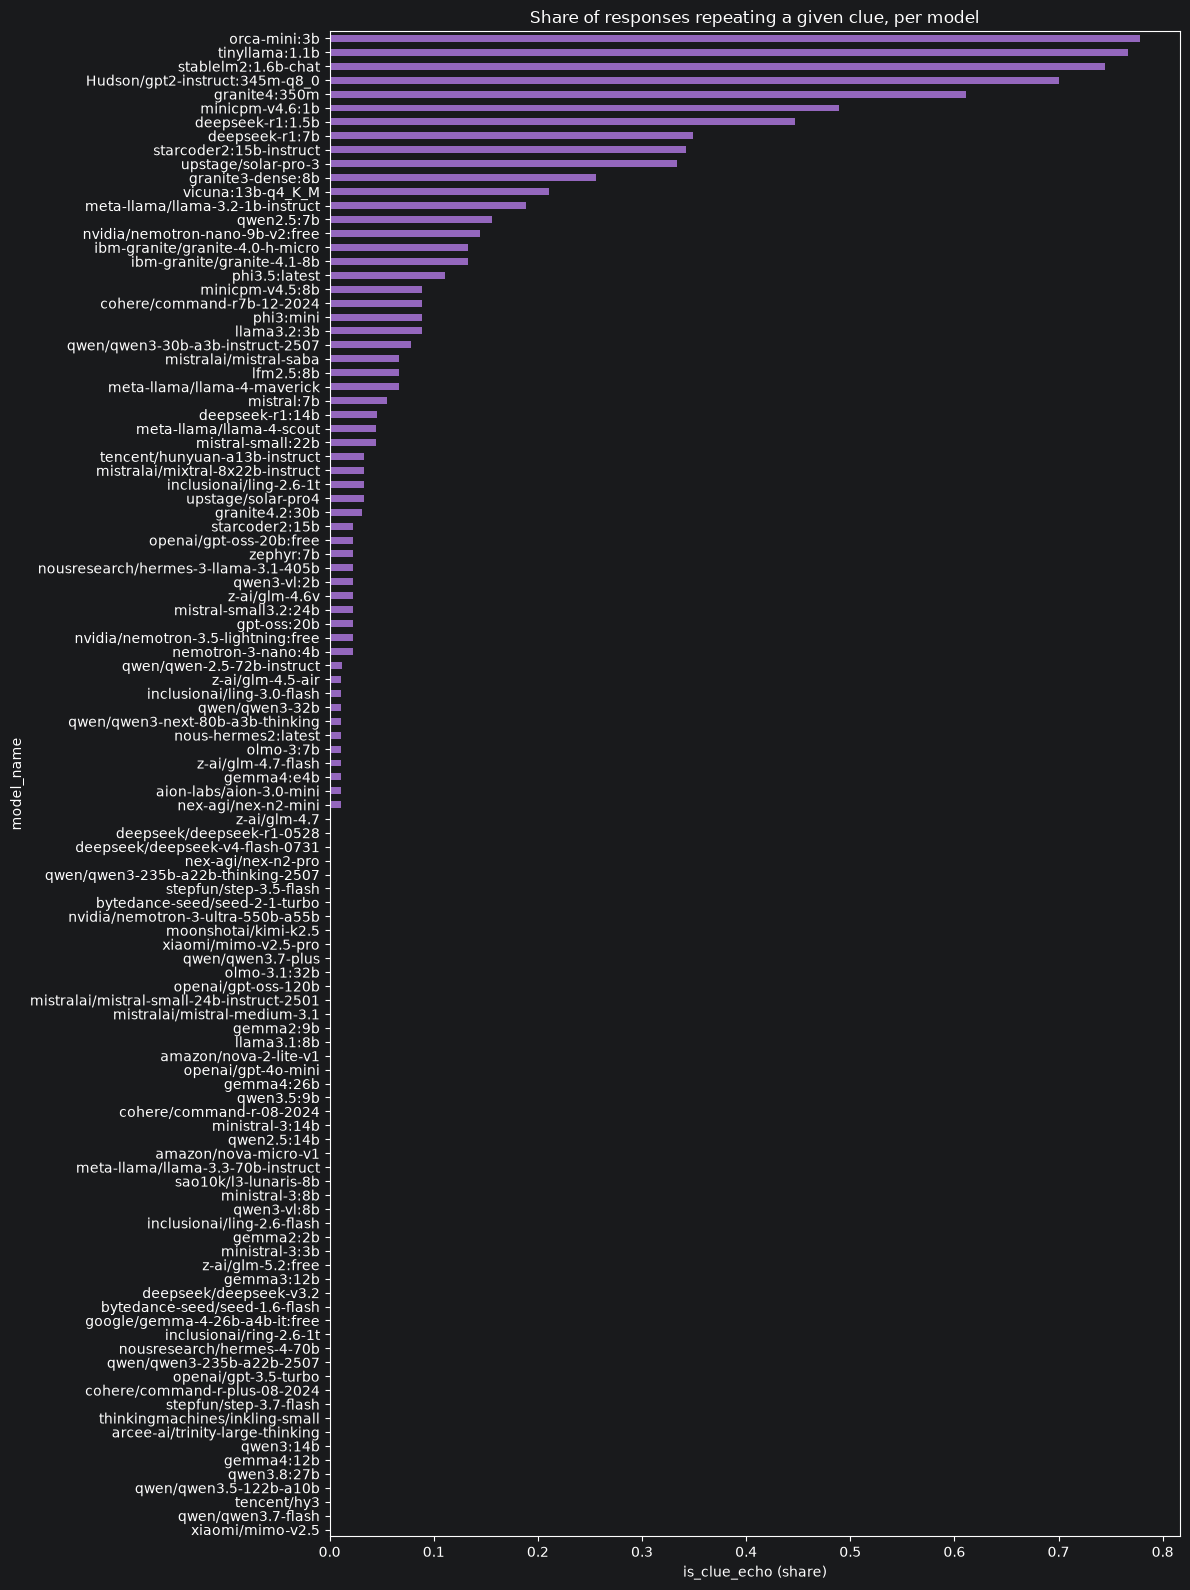

In [14]:
echo_rate = leaderboard["is_clue_echo"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 16))
echo_rate.sort_values().plot.barh(ax=ax, color="#9467bd")
ax.set_xlabel("is_clue_echo (share)")
ax.set_title("Share of responses repeating a given clue, per model")
plt.tight_layout()
plt.show()

## Difficulty per item

Two distinct checks: whether the difficulty tier you assigned by
hand is calibrated (mean accuracy decreasing from easy to hard — if
it doesn't decrease, that's a signal the labels are worth
revisiting), and which specific items turn out to be hardest for
*all* models together (an item at 0% for everyone is a candidate for
being genuinely ambiguous, not just difficult).


In [15]:
if "difficulty_note" in ok_data.columns:
    by_difficulty = ok_data.groupby("difficulty_note")["exact_match"].agg(["mean", "count"])
    print("Mean accuracy per declared difficulty tier:")
    print(by_difficulty.round(3))

Mean accuracy per declared difficulty tier:
                  mean  count
difficulty_note              
easy             0.487   1250
hard             0.320   3120
medium           0.407   5010


In [16]:
by_item = ok_data.groupby("prompt_id").agg(
    exact_match=("exact_match", "mean"),
    is_clue_echo=("is_clue_echo", "mean"),
    expected_solution=("expected_solution", "first"),
).sort_values("exact_match")

print("The 10 hardest items (lowest mean accuracy across all models):")
by_item.head(30).round(3)

The 10 hardest items (lowest mean accuracy across all models):


,exact_match,is_clue_echo,expected_solution
prompt_id,,,
guillo_10,0.000,0.058,pc
guillo_09,0.000,0.084,petrichor
guillo_23,0.000,0.029,concept
guillo_18,0.003,0.058,watching
guillo_29,0.003,0.156,scraping
guillo_21,0.013,0.080,supermarket
guillo_22,0.035,0.177,emotion
guillo_15,0.041,0.060,statistic
guillo_03,0.182,0.064,city


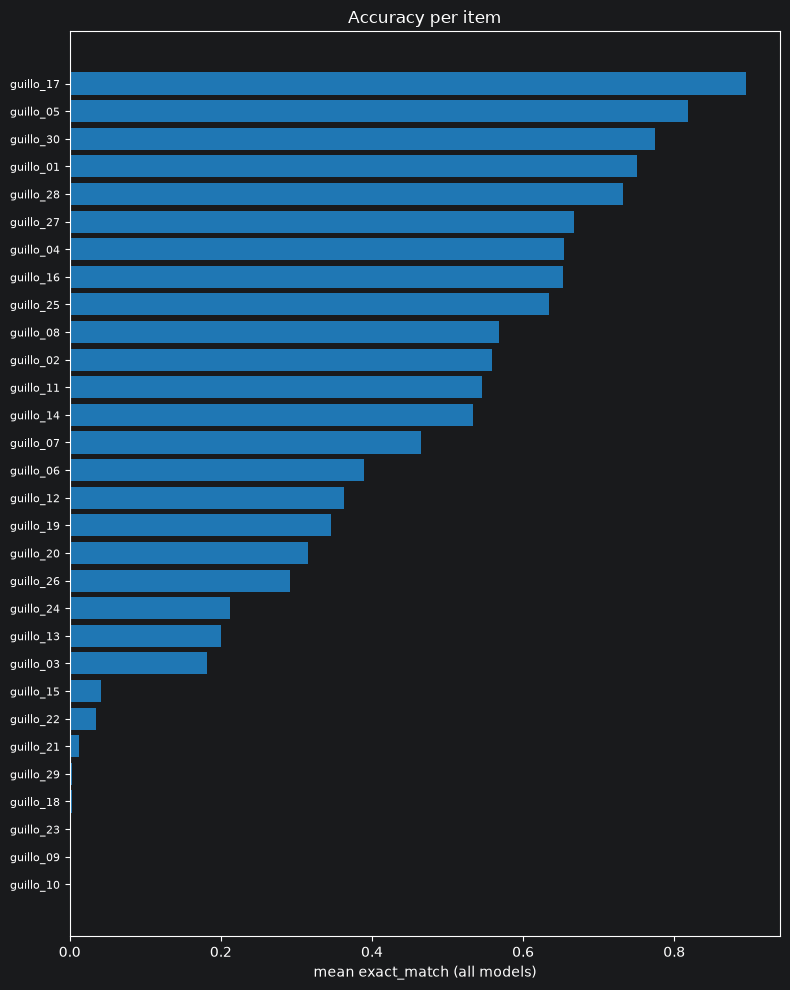

In [17]:
fig, ax = plt.subplots(figsize=(8, 10))
y = np.arange(len(by_item))
ax.barh(y, by_item["exact_match"], color="#1f77b4")
ax.set_yticks(y)
ax.set_yticklabels(by_item.index, fontsize=8)
ax.set_xlabel("mean exact_match (all models)")
ax.set_title("Accuracy per item")
plt.tight_layout()
plt.show()

## Zipf analysis: does word rarity explain difficulty?

Compares the lexical rarity (Zipf frequency, the standard logarithmic
scale from the `wordfreq` package: ~1-2 for very rare words, ~6-7 for
the most common ones in English) of the solution word and the clues
for each item against the mean accuracy already computed above in
`by_item` — to understand whether the harder items are hard because
the solution word is rare in the language, or for other reasons (task
structure, category genericity).

Requires the `wordfreq` package (`pip install wordfreq`, not included
in the base dependencies).


In [18]:
# Lexical rarity (Zipf) of solution and clues, per item.
try:
    from wordfreq import zipf_frequency
except ImportError as exc:
    raise ImportError(
        "Missing the 'wordfreq' package: install it with `pip install wordfreq` "
        "before re-running this cell."
    ) from exc

import json as _json
from scipy import stats

PROMPTS_FILE = Path(RESULT_FILES[0]).parent / "guillotine_prompts.json"
with open(PROMPTS_FILE, encoding="utf-8") as f:
    _prompts = {p["prompt_id"]: p for p in _json.load(f)["prompts"]}

zipf_rows = []
for prompt_id, p in _prompts.items():
    clue_zipfs = [zipf_frequency(w, "en") for w in p["clues"]]
    zipf_rows.append({
        "prompt_id": prompt_id,
        "solution": p["solution"],
        "zipf_solution": zipf_frequency(p["solution"], "en"),
        "zipf_clue_min": min(clue_zipfs),
        "zipf_clue_mean": sum(clue_zipfs) / len(clue_zipfs),
    })

zipf_df = pd.DataFrame(zipf_rows).set_index("prompt_id")
zipf_df = zipf_df.join(by_item["exact_match"]).sort_values("zipf_solution")

rho_sol, p_sol = stats.spearmanr(zipf_df["zipf_solution"], zipf_df["exact_match"])
rho_min, p_min = stats.spearmanr(zipf_df["zipf_clue_min"], zipf_df["exact_match"])
rho_mean, p_mean = stats.spearmanr(zipf_df["zipf_clue_mean"], zipf_df["exact_match"])

print(f"Spearman Zipf(solution) vs exact_match:   rho={rho_sol:.3f}, p={p_sol:.4f}")
print(f"Spearman Zipf(rarest clue) vs exact_match: rho={rho_min:.3f}, p={p_min:.4f}")
print(f"Spearman Zipf(mean clue) vs exact_match:   rho={rho_mean:.3f}, p={p_mean:.4f}")

zipf_df.round(3)

Spearman Zipf(solution) vs exact_match:   rho=0.241, p=0.1989
Spearman Zipf(rarest clue) vs exact_match: rho=0.210, p=0.2665
Spearman Zipf(mean clue) vs exact_match:   rho=0.189, p=0.3184


,solution,zipf_solution,zipf_clue_min,zipf_clue_mean,exact_match
prompt_id,,,,,
guillo_09,petrichor,1.60,3.37,4.054,0.000
guillo_14,mandala,2.78,3.31,4.078,0.534
guillo_29,scraping,3.33,3.61,4.416,0.003
guillo_13,surrogate,3.38,2.81,4.600,0.201
guillo_15,statistic,3.45,2.13,4.112,0.041
guillo_27,sustainability,3.77,3.91,4.704,0.668
guillo_11,python,3.78,3.06,3.902,0.546
guillo_21,supermarket,3.78,3.76,4.420,0.013
guillo_06,civilization,4.01,2.93,4.698,0.390


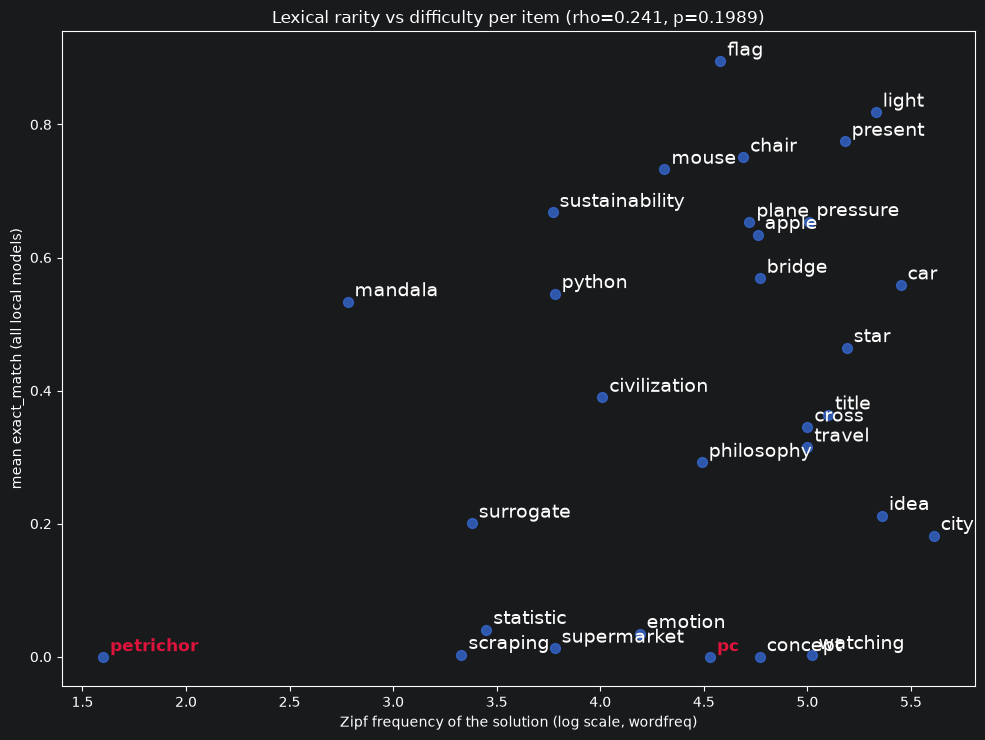

In [19]:
# Scatter of Zipf(solution) vs exact_match, 30 labeled items -
# highlights petrichor and pc, the two outliers at opposite extremes
# (rarest word in the dataset but "expected" difficulty; common word
# but structural, not lexical, difficulty).
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.scatter(zipf_df["zipf_solution"], zipf_df["exact_match"], alpha=0.75, s=50)

for prompt_id, row in zipf_df.iterrows():
    is_outlier = prompt_id in ("guillo_09", "guillo_10")
    ax.annotate(
        row["solution"],
        (row["zipf_solution"], row["exact_match"]),
        fontsize=12 if is_outlier else 14,
        color="crimson" if is_outlier else "white",
        fontweight="bold" if is_outlier else "normal",
        xytext=(5, 4), textcoords="offset points",
    )

ax.set_xlabel("Zipf frequency of the solution (log scale, wordfreq)")
ax.set_ylabel("mean exact_match (all local models)")
ax.set_title(f"Lexical rarity vs difficulty per item (rho={rho_sol:.3f}, p={p_sol:.4f})")
plt.tight_layout()
plt.show()

## Exporting summary tables

Saves the main tables as CSV, ready to be picked up in the whitepaper
without having to copy numbers by hand from the notebook.


In [20]:
OUTPUT_DIR = Path(RESULT_FILES[0]).parent
leaderboard.round(4).to_csv(OUTPUT_DIR / "analisi_leaderboard.csv")
temp_pivot.round(4).to_csv(OUTPUT_DIR / "analisi_temperatura.csv")
by_item.round(4).to_csv(OUTPUT_DIR / "analisi_per_item.csv")

print(f"Tables exported to {OUTPUT_DIR}")

Tables exported to D:\guillotine\guillotine\source


---
# Extensions: response frequency, statistical test on T, time/difficulty, same_root

## Response frequency per item

For a given `prompt_id`, the distribution of all responses given by
all models/temperatures — useful for seeing not only *whether* an
item is difficult but *how* models get it wrong: do they converge on
a valid synonym, on a repeated clue, or scatter randomly?


In [21]:
def response_frequency(prompt_id, data=ok_data, top=10):
    subset = data[data["prompt_id"] == prompt_id].copy()
    subset["predicted_norm"] = subset["predicted_word"].astype(str).str.strip().str.lower()
    counts = subset["predicted_norm"].value_counts().head(top)
    expected = subset["expected_solution"].iloc[0] if len(subset) else "?"
    print(f"{prompt_id} (expected: {expected!r}), {len(subset)} total responses:")
    return counts

# example: change prompt_id to look at a different item, e.g. "guillo_10" for PC
response_frequency("guillo_02")

guillo_02 (expected: 'car'), 315 total responses:


predicted_norm
car           175
vehicle        35
road           15
auto           14
insurance      10
motor           7
automobile      6
transport       6
truck           4
cover           3
Name: count, dtype: int64

guillo_02 (expected: 'car'), 315 total responses:


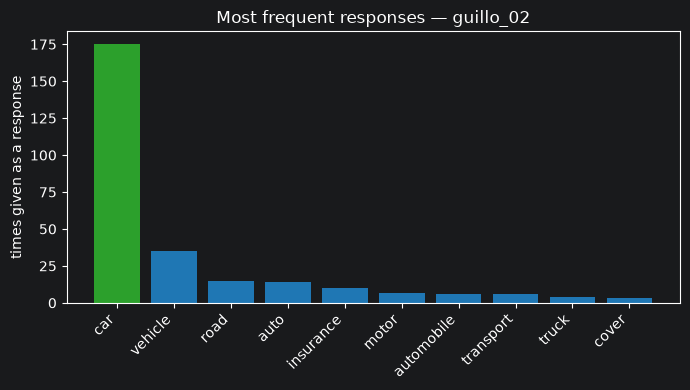

In [22]:
def plot_response_frequency(prompt_id, data=ok_data, top=10):
    counts = response_frequency(prompt_id, data, top)
    expected = data[data["prompt_id"] == prompt_id]["expected_solution"].iloc[0].lower()
    colors = ["#2ca02c" if w == expected else "#1f77b4" for w in counts.index]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_ylabel("times given as a response")
    ax.set_title(f"Most frequent responses — {prompt_id}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# example, change prompt_id to look at a different item
plot_response_frequency("guillo_02")

## Temperature: Cochran's Q, not chi-square

A chi-square test of independence would treat each cell as an
independent sample — but here it isn't: the same 30 items are
presented again to the same model at T=0.0, 0.3, and 0.7. It's a
repeated-measures design (same "subject," 3 conditions), not
independent samples. The correct test for comparing binary
proportions (correct/incorrect) across 3+ matched conditions is
**Cochran's Q** (a generalization of McNemar to more than 2
conditions), not chi-square.

Requires the item to be present at all 3 temperatures — timeouts
reduce the usable sample, and this must be stated, not hidden.


In [23]:
from statsmodels.stats.contingency_tables import cochrans_q

def temperature_cochran_q(model_name, data=ok_data):
    sub = data[data["model_name"] == model_name]
    pivot = sub.pivot_table(index="prompt_id", columns="temperature", values="exact_match")
    pivot_complete = pivot.dropna()

    print(f"{model_name}: items with all 3 T's present: {len(pivot_complete)}/{len(pivot)}")
    if len(pivot_complete) < 10:
        print("Fewer than 10 complete items - result should be interpreted with caution.")
    if len(pivot_complete) < 5:
        print("Too few for a reliable test, skipping.")
        return None

    result = cochrans_q(pivot_complete.values)
    print(f"Cochran's Q = {result.statistic:.3f}, p-value = {result.pvalue:.4f}")
    return result

# example on a reasoning model, where sensitivity to temperature
# is more plausible a priori
temperature_cochran_q("deepseek-r1:7b")

deepseek-r1:7b: items with all 3 T's present: 26/30
Cochran's Q = 6.333, p-value = 0.0421


<bunch containing results, print to see contents>

In [24]:
# Applied to all models with enough complete items
q_results = []
skipped_no_variance = []

for m in ok_data["model_name"].unique():
    sub = ok_data[ok_data["model_name"] == m]
    pivot = sub.pivot_table(index="prompt_id", columns="temperature", values="exact_match").dropna()
    if len(pivot) < 10:
        continue

    # Cochran's Q is undefined (0/0) if no item changes outcome across
    # temperatures - the model answers identically (right or wrong)
    # on every item at every T. This isn't an error, there's just nothing
    # to test: it's skipped with a note instead of letting statsmodels
    # produce NaN with a silent RuntimeWarning.
    n_varying_items = (pivot.min(axis=1) != pivot.max(axis=1)).sum()
    if n_varying_items == 0:
        skipped_no_variance.append(m)
        continue

    r = cochrans_q(pivot.values)
    q_results.append({
        "model_name": m, "n_complete_items": len(pivot),
        "n_varying_items": n_varying_items, "Q": r.statistic, "p_value": r.pvalue,
    })

q_df = pd.DataFrame(q_results).sort_values("p_value")
print(f"Models skipped (no item changes outcome across T, test undefined): {len(skipped_no_variance)}")
if skipped_no_variance:
    print(skipped_no_variance)

print(f"\nModels with p < 0.05 (accuracy depends on temperature, with this N):")
q_df[q_df["p_value"] < 0.05].round(4)

Models skipped (no item changes outcome across T, test undefined): 12
['granite4:350m', 'Hudson/gpt2-instruct:345m-q8_0', 'ibm-granite/granite-4.1-8b', 'inclusionai/ling-2.6-flash', 'meta-llama/llama-3.2-1b-instruct', 'meta-llama/llama-4-maverick', 'nousresearch/hermes-3-llama-3.1-405b', 'openai/gpt-3.5-turbo', 'orca-mini:3b', 'starcoder2:15b', 'tinyllama:1.1b', 'mistralai/mistral-medium-3.1']

Models with p < 0.05 (accuracy depends on temperature, with this N):


,model_name,n_complete_items,n_varying_items,Q,p_value
19,gemma4:26b,30,10,12.2000,0.0022
18,gemma4:12b,30,5,7.6000,0.0224
47,nousresearch/hermes-4-70b,30,6,7.0000,0.0302
20,gemma4:e4b,30,9,6.8889,0.0319
14,deepseek-r1:7b,26,6,6.3333,0.0421
79,tencent/hunyuan-a13b-instruct,30,9,6.2222,0.0446
76,starcoder2:15b-instruct,19,3,6.0000,0.0498
35,ministral-3:14b,30,3,6.0000,0.0498
81,thinkingmachines/inkling-small,30,4,6.0000,0.0498


## Generation time as a difficulty proxy — reasoning models only

Consistent with what we discussed: time variability makes sense as a
proxy for "how much the model had to think" only for reasoning models
(variable compute per token). Here we actually test it instead of
just arguing it qualitatively: mean time per item vs accuracy per
item, and mean time per declared difficulty tier.


In [25]:
reasoning_data = ok_data[
    ok_data["is_reasoning_model"] & (ok_data["is_first_call"] != 1) & ok_data["duration_s"].notna()
]

by_item_timing = reasoning_data.groupby("prompt_id").agg(
    duration_mean=("duration_s", "mean"),
    exact_match=("exact_match", "mean"),
    difficulty_note=("difficulty_note", "first"),
).sort_values("duration_mean", ascending=False)

corr_time_acc = by_item_timing["duration_mean"].corr(by_item_timing["exact_match"], method="spearman")
print(f"Spearman correlation mean time/accuracy per item (reasoning models): {corr_time_acc:.3f}")
print("(negative and strong = items that are slower to generate tend to have lower accuracy,")
print(" consistent with \"time as a difficulty proxy\" for this class of models)")

by_item_timing.head(30).round(2)

Spearman correlation mean time/accuracy per item (reasoning models): -0.672
(negative and strong = items that are slower to generate tend to have lower accuracy,
 consistent with "time as a difficulty proxy" for this class of models)


,duration_mean,exact_match,difficulty_note
prompt_id,,,
guillo_09,295.05,0.00,hard
guillo_29,260.93,0.01,hard
guillo_03,229.14,0.20,medium
guillo_24,191.06,0.26,hard
guillo_23,186.66,0.00,hard
guillo_11,162.47,0.69,medium
guillo_20,156.20,0.36,medium
guillo_22,146.48,0.00,medium
guillo_26,127.04,0.50,medium


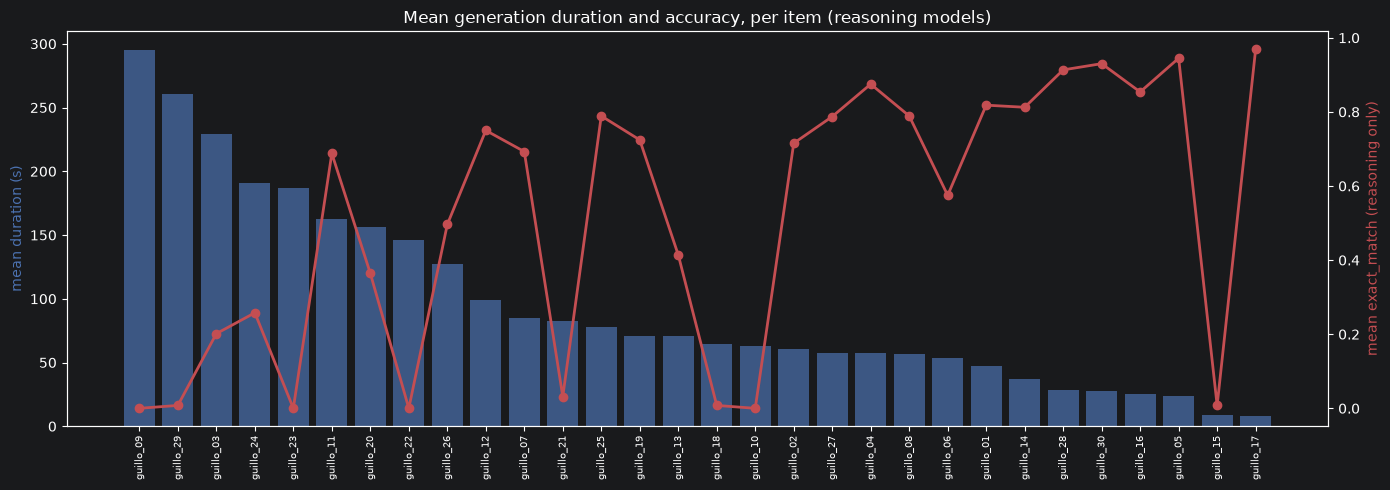

In [26]:
fig, ax1 = plt.subplots(figsize=(14, 5))
x = np.arange(len(by_item_timing))
ax1.bar(x, by_item_timing["duration_mean"], color="#4c72b0", alpha=0.7)
ax1.set_ylabel("mean duration (s)", color="#4c72b0")
ax1.set_xticks(x)
ax1.set_xticklabels(by_item_timing.index, rotation=90, fontsize=7)

ax2 = ax1.twinx()
ax2.plot(x, by_item_timing["exact_match"], color="#c44e52", marker="o", linewidth=2)
ax2.set_ylabel("mean exact_match (reasoning only)", color="#c44e52")

ax1.set_title("Mean generation duration and accuracy, per item (reasoning models)")
fig.tight_layout()
plt.show()

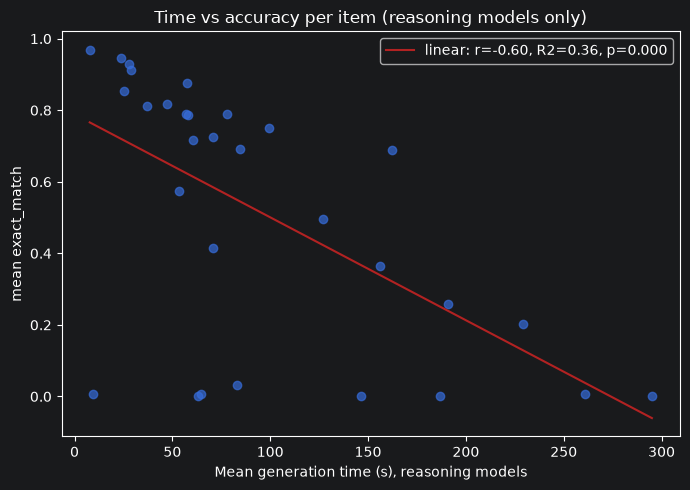

Spearman rho = -0.672 (p=0.0000) - reported above, it's the primary measure:
it captures the monotonic relationship without assuming linearity, robust to the point
in the upper left, which is clearly a potential outlier in the scatter.

Time per declared difficulty tier (reasoning models):


,mean,std,count
difficulty_note,,,
easy,62.4,159.8,506
hard,124.8,308.5,1277
medium,85.1,250.0,2047


In [27]:
from scipy import stats

fig, ax = plt.subplots(figsize=(7, 5))
x, y = by_item_timing["duration_mean"].values, by_item_timing["exact_match"].values

ax.scatter(x, y, alpha=0.7)

# Linear regression line (degree 1) - see the cell below for why
# we don't go further: with this N, higher degrees worsen predictive
# capability even though the in-sample R2 looks better.
lin = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 50)
ax.plot(x_line, lin.intercept + lin.slope * x_line, color="firebrick",
        label=f"linear: r={lin.rvalue:.2f}, R2={lin.rvalue**2:.2f}, p={lin.pvalue:.3f}")
ax.legend()

ax.set_xlabel("Mean generation time (s), reasoning models")
ax.set_ylabel("mean exact_match")
ax.set_title("Time vs accuracy per item (reasoning models only)")
plt.tight_layout()
plt.show()

rho, p_rho = stats.spearmanr(x, y)
print(f"Spearman rho = {rho:.3f} (p={p_rho:.4f}) - reported above, it's the primary measure:")
print("it captures the monotonic relationship without assuming linearity, robust to the point")
print("in the upper left, which is clearly a potential outlier in the scatter.")

by_diff_timing = reasoning_data.groupby("difficulty_note")["duration_s"].agg(["mean", "std", "count"])
print("\nTime per declared difficulty tier (reasoning models):")
by_diff_timing.round(1)

## `same_root`: how much it adds on top of `exact_match`

`same_root` is always a superset of `exact_match` (verified: zero
rows with `exact_match=1` and `same_root=0` — logical, since the same
word always shares its own root). So in the leaderboard,
`same_root=0.785` does **not** mean "78.5% additional," it means
"78.5% total, of which part is already in exact matches." The column
below isolates only the true increment (`same_root` but not
`exact_match` — plurals, conjugations, non-exact morphological
variations).


In [28]:
violation_mask = (ok_data["exact_match"] == 1) & (ok_data["same_root"] == 0)
n_violations = violation_mask.sum()

if n_violations:
    print(f"WARNING: {n_violations} rows with exact_match=1 but same_root=0 (expected: 0).")
    print("Likely cause: predicted_word corrected by hand without re-running rescore.py afterward.")
    print("Rows involved, per model:")
    print(ok_data.loc[violation_mask, "model_name"].value_counts())
else:
    print("No violations: same_root is always a superset of exact_match, as expected.")

ok_data["same_root_only"] = ((ok_data["same_root"] == 1) & (ok_data["exact_match"] == 0)).astype(int)

breakdown = ok_data.groupby("model_name").agg(
    exact_match=("exact_match", "mean"),
    same_root_only=("same_root_only", "mean"),
).sort_values("exact_match", ascending=False)
breakdown["same_root_total"] = breakdown["exact_match"] + breakdown["same_root_only"]

breakdown.round(3)

Likely cause: predicted_word corrected by hand without re-running rescore.py afterward.
Rows involved, per model:
model_name
deepseek-r1:7b             1
qwen2.5:14b                1
starcoder2:15b-instruct    1
Name: count, dtype: int64


,exact_match,same_root_only,same_root_total
model_name,,,
z-ai/glm-5.2:free,0.750,0.000,0.750
stepfun/step-3.5-flash,0.711,0.067,0.778
bytedance-seed/seed-2-1-turbo,0.678,0.067,0.744
nvidia/nemotron-3-ultra-550b-a55b,0.678,0.067,0.744
moonshotai/kimi-k2.5,0.663,0.067,0.730
...,...,...,...
Hudson/gpt2-instruct:345m-q8_0,0.000,0.022,0.022
meta-llama/llama-3.2-1b-instruct,0.000,0.000,0.000
granite4:350m,0.000,0.000,0.000


---
# Full statistical picture

Requires `synonym_manual`/`coherence_manual` to be filled in (they
are, 100%) to make full sense - some sections below would be barely
informative with a partial review.


## Confidence intervals on the leaderboard (Wilson score)

Each accuracy rate is a proportion over ~90 trials (30 items × 3
temperatures, minus timeouts) — a point estimate without an interval
hides how uncertain it is. Wilson instead of Wald/normal because it's
more reliable with proportions close to 0 or 1 and samples that
aren't huge, exactly our case.


In [29]:
from statsmodels.stats.proportion import proportion_confint

leaderboard_ci = ok_data.groupby("model_name").agg(
    n=("exact_match", "size"), exact_match=("exact_match", "mean"),
).sort_values("exact_match", ascending=False)

successes = (leaderboard_ci["exact_match"] * leaderboard_ci["n"]).round().astype(int)
leaderboard_ci["ci_low"], leaderboard_ci["ci_high"] = proportion_confint(
    successes, leaderboard_ci["n"], method="wilson"
)
leaderboard_ci.round(3)

,n,exact_match,ci_low,ci_high
model_name,,,,
z-ai/glm-5.2:free,4,0.750,0.301,0.954
stepfun/step-3.5-flash,90,0.711,0.610,0.795
bytedance-seed/seed-2-1-turbo,90,0.678,0.576,0.765
nvidia/nemotron-3-ultra-550b-a55b,90,0.678,0.576,0.765
moonshotai/kimi-k2.5,89,0.663,0.560,0.753
...,...,...,...,...
Hudson/gpt2-instruct:345m-q8_0,90,0.000,0.000,0.041
meta-llama/llama-3.2-1b-instruct,90,0.000,0.000,0.041
granite4:350m,90,0.000,0.000,0.041


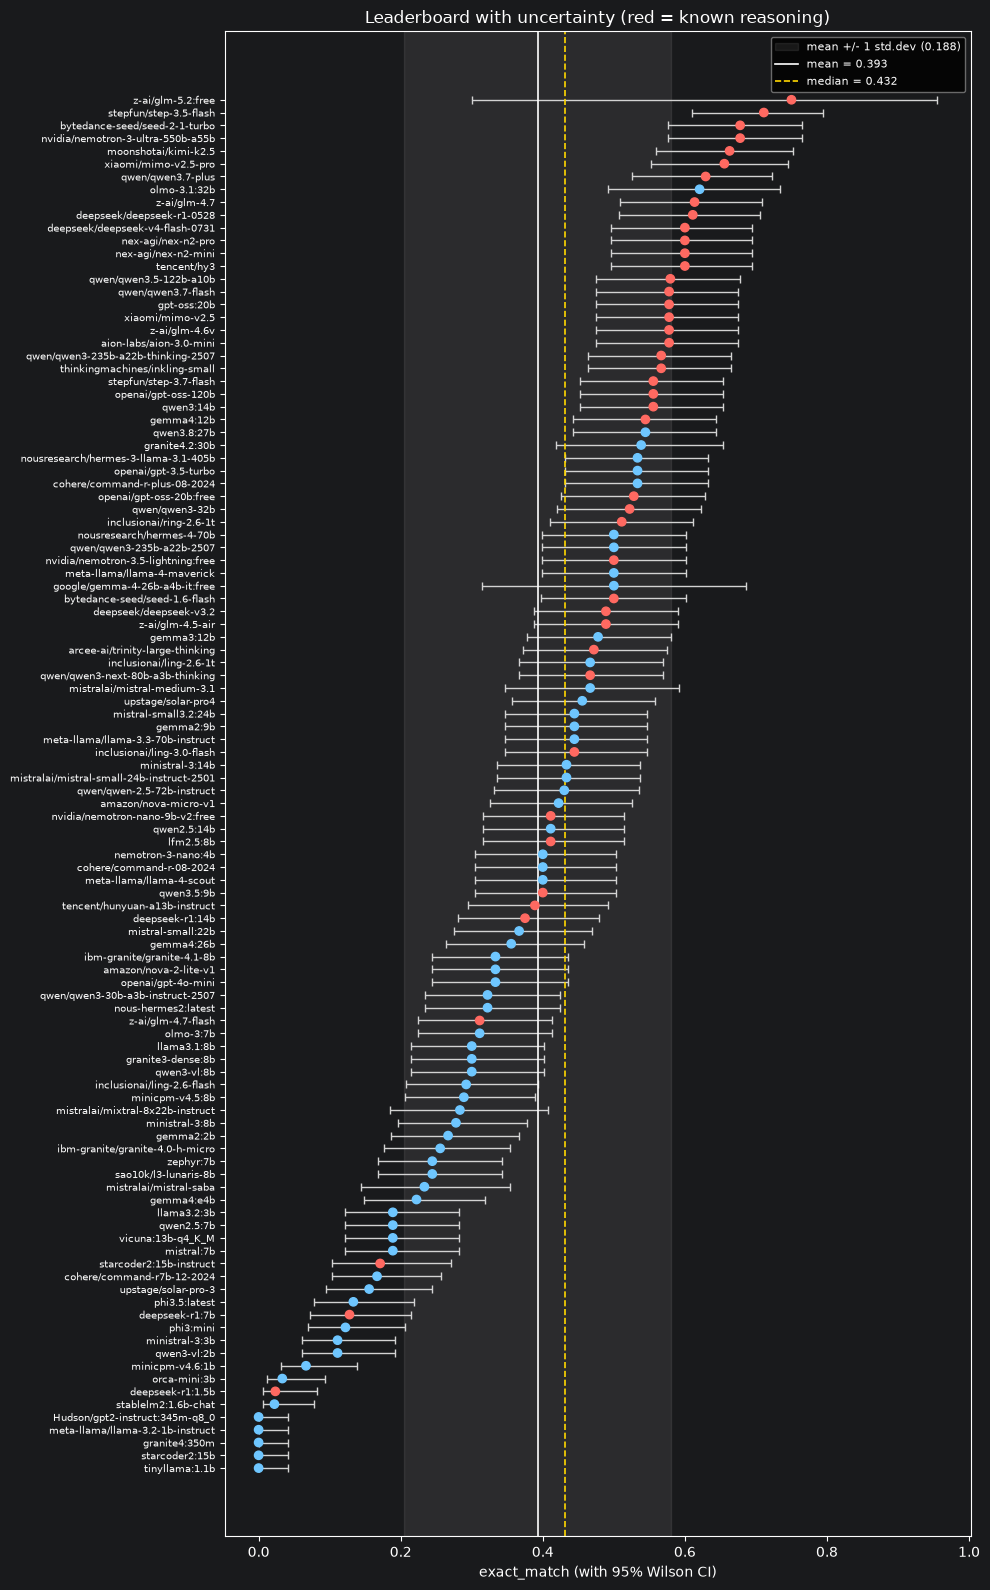

In [30]:
fig, ax = plt.subplots(figsize=(10, 16))
y = np.arange(len(leaderboard_ci))
colors = ["#ff6961" if is_reasoning_model(m) else "#6ec6ff" for m in leaderboard_ci.index]

ax.errorbar(
    leaderboard_ci["exact_match"], y,
    xerr=[leaderboard_ci["exact_match"] - leaderboard_ci["ci_low"],
          leaderboard_ci["ci_high"] - leaderboard_ci["exact_match"]],
    fmt="none", ecolor="lightgray", elinewidth=1, capsize=3, zorder=2,
)
ax.scatter(leaderboard_ci["exact_match"], y, color=colors, zorder=3)

mean_val = leaderboard_ci["exact_match"].mean()
median_val = leaderboard_ci["exact_match"].median()
std_val = leaderboard_ci["exact_match"].std()

ax.axvspan(mean_val - std_val, mean_val + std_val, color="white", alpha=0.08,
           label=f"mean +/- 1 std.dev ({std_val:.3f})")
ax.axvline(mean_val, color="white", linestyle="-", linewidth=1.2,
           label=f"mean = {mean_val:.3f}")
ax.axvline(median_val, color="gold", linestyle="--", linewidth=1.2,
           label=f"median = {median_val:.3f}")
ax.legend(fontsize=8, facecolor="black", edgecolor="gray", labelcolor="white")

ax.set_yticks(y)
ax.set_yticklabels(leaderboard_ci.index, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("exact_match (with 95% Wilson CI)")
ax.set_title("Leaderboard with uncertainty (red = known reasoning)")
plt.tight_layout()
plt.show()

## Extended correctness: exact / +same_root / +synonym_manual

Now that `synonym_manual` is 100% complete, this is probably the most
honest metric for RQ1 — not just exact match, but everything you
judged to be a valid response, broken down to understand where each
increment comes from.


In [31]:
ok_data["same_root_only"] = ((ok_data["same_root"] == 1) & (ok_data["exact_match"] == 0)).astype(int)
ok_data["synonym_only"] = (
    (ok_data["synonym_manual"] == 1) & (ok_data["exact_match"] == 0) & (ok_data["same_root"] == 0)
).astype(int)
ok_data["broad_correct"] = (
    (ok_data["exact_match"] == 1) | (ok_data["same_root"] == 1) | (ok_data["synonym_manual"] == 1)
).astype(int)

extended = ok_data.groupby("model_name").agg(
    exact_match=("exact_match", "mean"),
    same_root_only=("same_root_only", "mean"),
    synonym_only=("synonym_only", "mean"),
    broad_correct=("broad_correct", "mean"),
).sort_values("broad_correct", ascending=False)

extended.round(3)

,exact_match,same_root_only,synonym_only,broad_correct
model_name,,,,
bytedance-seed/seed-2-1-turbo,0.678,0.067,0.056,0.800
nvidia/nemotron-3-ultra-550b-a55b,0.678,0.067,0.044,0.789
stepfun/step-3.5-flash,0.711,0.067,0.011,0.789
moonshotai/kimi-k2.5,0.663,0.067,0.034,0.764
xiaomi/mimo-v2.5-pro,0.656,0.067,0.033,0.756
...,...,...,...,...
stablelm2:1.6b-chat,0.022,0.000,0.011,0.033
meta-llama/llama-3.2-1b-instruct,0.000,0.000,0.000,0.000
granite4:350m,0.000,0.000,0.000,0.000


## Automatic/manual agreement (Cohen's Kappa)

How much do the automatic metrics (`same_root` or `is_similar_lev`)
already capture on their own what you judged to be a valid synonym,
among the non-exact responses? If agreement is low, the manual review
wasn't a cautious extra, it was necessary — this quantifies that
instead of assuming it.


In [32]:
from statsmodels.stats.inter_rater import cohens_kappa

not_exact = ok_data[ok_data["exact_match"] == 0].copy()
n_before = len(not_exact)
not_exact = not_exact[not_exact["synonym_manual"].notna()].copy()
n_missing_review = n_before - len(not_exact)
if n_missing_review:
    print(f"{n_missing_review} non-exact rows without synonym_manual filled in, excluded from this comparison.")

if len(not_exact) < 10:
    print(f"Only {len(not_exact)} rows with synonym_manual filled in among the non-exact ones - "
          f"too few for a reliable Kappa. Re-run this cell once the review is more advanced.")
else:
    not_exact["auto_flag"] = ((not_exact["same_root"] == 1) | (not_exact["is_similar_lev"] == 1)).astype(int)
    not_exact["manual_flag"] = not_exact["synonym_manual"].astype(int)

    table = pd.crosstab(not_exact["auto_flag"], not_exact["manual_flag"])
    print("Automatic (rows) vs manual synonym (columns), among the non-exact ones:")
    print(table)

    kappa_result = cohens_kappa(table.values)
    agreement_pct = (not_exact["auto_flag"] == not_exact["manual_flag"]).mean()
    missed = ((not_exact["auto_flag"] == 0) & (not_exact["manual_flag"] == 1)).sum()

    print(f"\nCohen's Kappa: {kappa_result.kappa:.3f}")
    print(f"Raw agreement: {agreement_pct:.1%}")
    print(f"Valid synonyms that the automatic metric alone would NOT have caught: {missed} rows")

Automatic (rows) vs manual synonym (columns), among the non-exact ones:
manual_flag     0    1
auto_flag             
0            4662  468
1             570   32

Cohen's Kappa: -0.041
Raw agreement: 81.9%
Valid synonyms that the automatic metric alone would NOT have caught: 468 rows


## Item discrimination index (Classical Test Theory)

Borrowed from psychometrics: for each item, the point-biserial
correlation between "the model solves it" and "the model's total
score on the *other* 29 items" (corrected to avoid part-whole
inflation). An item with high discrimination separates strong models
from weak ones well — one with low or negative discrimination doesn't
track general capability, likely due to a problem in the item itself,
not in the models.

Items where *all* models agree (0% or 100% for everyone) aren't
testable: no variance to correlate, not an error.


In [33]:
from scipy.stats import pointbiserialr

item_model_matrix = ok_data.pivot_table(index="model_name", columns="prompt_id", values="exact_match", aggfunc="mean")

discrimination, difficulty_p, skipped_constant = {}, {}, []
for item in item_model_matrix.columns:
    item_scores = item_model_matrix[item]
    total_minus_item = item_model_matrix.drop(columns=[item]).mean(axis=1)
    valid = item_scores.notna() & total_minus_item.notna()
    if valid.sum() < 5:
        continue
    difficulty_p[item] = item_scores.mean()
    if item_scores[valid].nunique() < 2:
        skipped_constant.append(item)
        continue
    r, _ = pointbiserialr(item_scores[valid], total_minus_item[valid])
    discrimination[item] = r

disc_df = pd.DataFrame({"difficulty_p": pd.Series(difficulty_p), "discrimination": pd.Series(discrimination)})
disc_df_ranked = disc_df.dropna(subset=["discrimination"]).sort_values("discrimination")

print(f"Non-testable items (no variance across models): {skipped_constant}")
print("\nItems with lowest discrimination (candidates for review, like guillo_08/19/25 previously):")
disc_df_ranked.head(8).round(3)

Non-testable items (no variance across models): ['guillo_09', 'guillo_10', 'guillo_23']

Items with lowest discrimination (candidates for review, like guillo_08/19/25 previously):


,difficulty_p,discrimination
guillo_15,0.040,-0.161
guillo_18,0.003,-0.146
guillo_22,0.034,-0.094
guillo_03,0.184,0.069
guillo_21,0.012,0.122
guillo_29,0.003,0.142
guillo_24,0.212,0.263
guillo_20,0.314,0.293


## Ranking stability across temperatures

This is not "cross-validation" in the strict sense — that's a
technique for validating a predictive model, and we're not training
one here. The correct equivalent of your question ("are the
computations consistent across temperatures?") is to check whether
the **model ranking by accuracy** stays stable at different T's: if
so, temperature shifts absolute accuracy by a few points but doesn't
flip who is better than whom (a sign of reliable measurement); if the
ranking changed a lot, that would be a serious problem, either with
the design or the metric.


In [34]:
from scipy.stats import spearmanr

rank_by_temp = ok_data.pivot_table(index="model_name", columns="temperature", values="exact_match", aggfunc="mean")

temps = rank_by_temp.columns.tolist()
print("Spearman correlation between model rankings, pairwise across temperatures:")
for i in range(len(temps)):
    for j in range(i + 1, len(temps)):
        valid = rank_by_temp[[temps[i], temps[j]]].dropna()
        rho, p = spearmanr(valid[temps[i]], valid[temps[j]])
        print(f"  T={temps[i]} vs T={temps[j]}: rho={rho:.3f} (p={p:.4f}, n={len(valid)})")

Spearman correlation between model rankings, pairwise across temperatures:
  T=0.0 vs T=0.3: rho=0.920 (p=0.0000, n=105)
  T=0.0 vs T=0.7: rho=0.886 (p=0.0000, n=104)
  T=0.3 vs T=0.7: rho=0.930 (p=0.0000, n=107)


## Pairwise comparison between models (McNemar + multiple-comparison correction)

McNemar is the correct test for comparing two models on the **same**
items (paired data) — not a chi-square, same principle as Cochran's Q
but for 2 conditions instead of 3. Limited to the top 8 models in the
leaderboard to keep the number of comparisons manageable; with more
models the FDR correction (Benjamini-Hochberg) below would still be
needed, otherwise the risk of false positives grows with every
additional comparison.


In [35]:
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
from itertools import combinations

top_models = ok_data.groupby("model_name")["exact_match"].mean().sort_values(ascending=False).head(8).index.tolist()

pair_results = []
for m1, m2 in combinations(top_models, 2):
    d1 = ok_data[ok_data["model_name"] == m1].groupby("prompt_id")["exact_match"].mean()
    d2 = ok_data[ok_data["model_name"] == m2].groupby("prompt_id")["exact_match"].mean()
    common = d1.index.intersection(d2.index)
    if len(common) < 10:
        continue
    b1, b2 = (d1[common] >= 0.5).astype(int), (d2[common] >= 0.5).astype(int)
    table = pd.crosstab(b1, b2).reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    # If the two discordant cells are both zero (the two models agree on
    # every item, always both right or both wrong), McNemar's asymptotic
    # formula divides by (n1+n2)=0 - the same principle as the degenerate
    # case already handled for Cochran's Q. This isn't an error, there's
    # just no discordance to test: no evidence of a difference, p=1.0 by
    # construction, without statsmodels' warning.
    n1, n2 = table.values[0, 1], table.values[1, 0]
    if n1 + n2 == 0:
        pair_results.append({"model_1": m1, "model_2": m2, "n_items": len(common), "p_value": 1.0})
        continue

    result = mcnemar(table.values, exact=(len(common) < 25))
    pair_results.append({"model_1": m1, "model_2": m2, "n_items": len(common), "p_value": result.pvalue})

pair_df = pd.DataFrame(pair_results)
if len(pair_df):
    pair_df["p_value_fdr_corrected"] = multipletests(pair_df["p_value"], method="fdr_bh")[1]
    pair_df = pair_df.sort_values("p_value_fdr_corrected")

print(f"Pairs with a still-significant difference after FDR correction (p<0.05): "
      f"{(pair_df['p_value_fdr_corrected'] < 0.05).sum()}/{len(pair_df)}")
pair_df.round(4)

Pairs with a still-significant difference after FDR correction (p<0.05): 0/21


,model_1,model_2,n_items,p_value,p_value_fdr_corrected
0,stepfun/step-3.5-flash,bytedance-seed/seed-2-1-turbo,30,1.0000,1.0
1,stepfun/step-3.5-flash,nvidia/nemotron-3-ultra-550b-a55b,30,1.0000,1.0
2,stepfun/step-3.5-flash,moonshotai/kimi-k2.5,30,0.4795,1.0
3,stepfun/step-3.5-flash,xiaomi/mimo-v2.5-pro,30,1.0000,1.0
4,stepfun/step-3.5-flash,qwen/qwen3.7-plus,30,0.4795,1.0
5,stepfun/step-3.5-flash,olmo-3.1:32b,27,0.4795,1.0
6,bytedance-seed/seed-2-1-turbo,nvidia/nemotron-3-ultra-550b-a55b,30,1.0000,1.0
7,bytedance-seed/seed-2-1-turbo,moonshotai/kimi-k2.5,30,0.4795,1.0
8,bytedance-seed/seed-2-1-turbo,xiaomi/mimo-v2.5-pro,30,1.0000,1.0
9,bytedance-seed/seed-2-1-turbo,qwen/qwen3.7-plus,30,0.4795,1.0


## Bootstrap CI for the size/accuracy correlation (RQ5)

A single correlation number over ~26 models doesn't convey how
uncertain it is. Per-model bootstrap (resampling with replacement of
the "model" row, not individual responses) for a confidence interval,
instead of just the point estimate already seen above.


In [36]:
rng = np.random.default_rng(0)
n_boot = 2000
boot_corrs = []
idx = size_df.index.to_numpy()

for _ in range(n_boot):
    sample = rng.choice(idx, size=len(idx), replace=True)
    s = size_df.loc[sample]
    if s["size_b"].nunique() < 2 or s["exact_match"].nunique() < 2:
        continue
    rho, _ = spearmanr(s["size_b"], s["exact_match"])
    boot_corrs.append(rho)

boot_corrs = np.array(boot_corrs)
ci_low, ci_high = np.percentile(boot_corrs, [2.5, 97.5])
print(f"Spearman rho (point estimate, from above): {corr:.3f}")
print(f"Bootstrap 95% CI ({len(boot_corrs)} valid resamples out of {n_boot}): [{ci_low:.3f}, {ci_high:.3f}]")

Spearman rho (point estimate, from above): 0.827
Bootstrap 95% CI (2000 valid resamples out of 2000): [0.701, 0.910]


## Why not a high-degree polynomial

With N=30 items, a degree 3-4 polynomial has 4-5 free parameters to
estimate — enough to chase noise instead of a real pattern. In-sample
R² always increases with degree (more free parameters can always fit
the points they've seen better), so it's not a valid criterion for
choosing the degree. What matters is whether the model generalizes to
a point it hasn't seen — tested here with leave-one-out: refit
excluding one item at a time, predict the excluded one, repeat for
all 30.


In [37]:
degrees = [1, 2, 3, 4]
x, y = by_item_timing["duration_mean"].values, by_item_timing["exact_match"].values

results = []
for deg in degrees:
    # In-sample R2: how well the polynomial fits the data it has seen
    coeffs = np.polyfit(x, y, deg)
    y_pred_in_sample = np.polyval(coeffs, x)
    r2_in_sample = 1 - np.sum((y - y_pred_in_sample)**2) / np.sum((y - y.mean())**2)

    # Leave-one-out R2: how well it generalizes to a point never seen
    loocv_preds = np.zeros(len(x))
    for i in range(len(x)):
        mask = np.ones(len(x), dtype=bool)
        mask[i] = False
        coeffs_i = np.polyfit(x[mask], y[mask], deg)
        loocv_preds[i] = np.polyval(coeffs_i, x[i])
    r2_loocv = 1 - np.sum((y - loocv_preds)**2) / np.sum((y - y.mean())**2)

    results.append({"degree": deg, "free_parameters": deg + 1,
                     "R2_in_sample": r2_in_sample, "R2_leave_one_out": r2_loocv})

degree_df = pd.DataFrame(results).set_index("degree")
print("Negative R2 = the model at that degree predicts worse than the simple mean.")
degree_df.round(3)

Negative R2 = the model at that degree predicts worse than the simple mean.


,free_parameters,R2_in_sample,R2_leave_one_out
degree,,,
1,2,0.356,0.281
2,3,0.358,0.222
3,4,0.359,0.134
4,5,0.363,-0.061


## Distribution of responses per model

Not a histogram of accuracy (that would collapse model identity,
which we want to keep here) — a stacked bar that breaks down each
model's score into the same categories as the "extended correctness"
section above: how much comes from an exact match, how much from a
shared root, how much from a manually judged synonym, and how much
remains wrong. It shows *where* the score comes from, not just how
much it is.


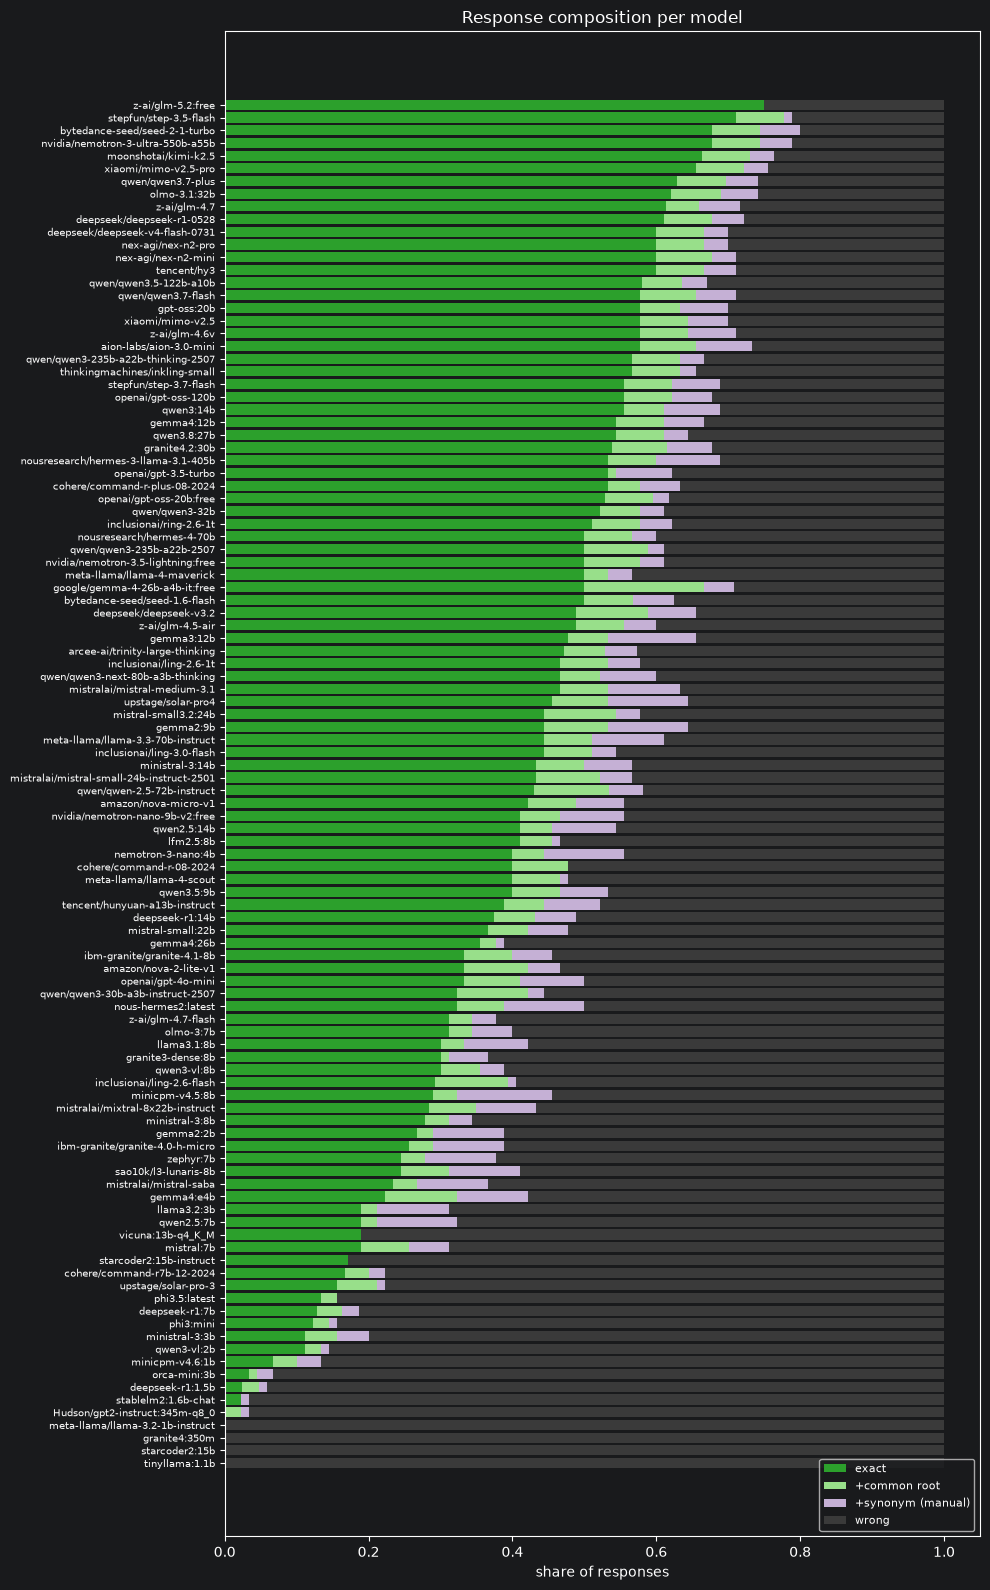

In [38]:
extended_plot = ok_data.groupby("model_name").agg(
    exact_match=("exact_match", "mean"),
    same_root_only=("same_root_only", "mean"),
    synonym_only=("synonym_only", "mean"),
).sort_values("exact_match", ascending=False)
extended_plot["wrong"] = 1 - extended_plot.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 16))
y = np.arange(len(extended_plot))
left = np.zeros(len(extended_plot))
colors = {"exact_match": "#2ca02c", "same_root_only": "#98df8a",
          "synonym_only": "#c5b0d5", "wrong": "#3a3a3a"}
labels = {"exact_match": "exact", "same_root_only": "+common root",
          "synonym_only": "+synonym (manual)", "wrong": "wrong"}

for col in ["exact_match", "same_root_only", "synonym_only", "wrong"]:
    ax.barh(y, extended_plot[col], left=left, color=colors[col], label=labels[col])
    left += extended_plot[col].values

ax.set_yticks(y)
ax.set_yticklabels(extended_plot.index, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("share of responses")
ax.set_title("Response composition per model")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

---
# Verified parameters and full preliminary statistical analysis

## Verified parameter count (not from the tag)

Looked up on official model cards/technical reports for each model,
not derived from the Ollama tag name. For **Mixture-of-Experts**
models or ones with **Per-Layer Embeddings** (small Gemma 4 models),
the "active" parameters per token are much smaller than the total
checkpoint - these are two different measures of "size," and using
them interchangeably is imprecise.

Found a notable case while verifying: **`gpt-oss:20b`** has 20.9B
total parameters but only **3.61B active per token** (MoE, 32
experts, top-4 routing) - it looks "large" from the tag, but in terms
of what the model computes per token it's among the smallest in your
whole roster.


In [39]:
# Parameters VERIFIED against primary sources (model card/technical report),
# not derived from the Ollama tag. total = full checkpoint, active =
# parameters used per token (= total for dense models).
VERIFIED_PARAMS = {
    "tinyllama:1.1b":                 {"total": 1.10,  "active": 1.10},
    "Hudson/gpt2-instruct:345m-q8_0": {"total": 0.345, "active": 0.345},
    "stablelm2:1.6b-chat":            {"total": 1.60,  "active": 1.60},
    "orca-mini:3b":                   {"total": 3.00,  "active": 3.00},
    "llama3.2:3b":                    {"total": 3.21,  "active": 3.21},
    "phi3:mini":                      {"total": 3.80,  "active": 3.80},
    "phi3.5:latest":                  {"total": 3.80,  "active": 3.80},
    "deepseek-r1:1.5b":               {"total": 1.50,  "active": 1.50},
    "nemotron-3-nano:4b":             {"total": 4.00,  "active": 4.00},
    "gemma2:2b":                      {"total": 2.61,  "active": 2.61},
    "llama3.1:8b":                    {"total": 8.03,  "active": 8.03},
    "qwen2.5:7b":                     {"total": 7.61,  "active": 7.61},
    "mistral:7b":                     {"total": 7.24,  "active": 7.24},
    "zephyr:7b":                      {"total": 7.24,  "active": 7.24},
    "deepseek-r1:7b":                 {"total": 7.61,  "active": 7.61},
    "granite3-dense:8b":              {"total": 8.17,  "active": 8.17},
    "gemma4:e4b":                     {"total": 8.00,  "active": 4.50},
    "gemma2:9b":                      {"total": 9.24,  "active": 9.24},
    "qwen3.5:9b":                     {"total": 9.00,  "active": 9.00},
    "nous-hermes2:latest":            {"total": 10.7,  "active": 10.7},
    "vicuna:13b-q4_K_M":              {"total": 13.0,  "active": 13.0},
    "gemma3:12b":                     {"total": 12.2,  "active": 12.2},
    "gemma4:12b":                     {"total": 12.0,  "active": 12.0},
    "qwen2.5:14b":                    {"total": 14.7,  "active": 14.7},
    "deepseek-r1:14b":                {"total": 14.7,  "active": 14.7},
    "qwen3:14b":                      {"total": 14.8,  "active": 14.8},
    "starcoder2:15b":                 {"total": 15.5,  "active": 15.5},
    "starcoder2:15b-instruct":        {"total": 15.5,  "active": 15.5},
    "mistral-small:22b":              {"total": 22.2,  "active": 22.2},
    "gpt-oss:20b":                    {"total": 20.9,  "active": 3.61},
    # Added - from the tag, not from an individually verified technical
    # sheet (standard dense models, the Ollama tag is reliable for these).
    "qwen3-vl:2b":                    {"total": 2.0,   "active": 2.0},
    "qwen3-vl:8b":                    {"total": 8.0,   "active": 8.0},
    "granite4:350m":                  {"total": 0.35,  "active": 0.35},
    "granite4.2:30b":                 {"total": 30.0,  "active": 30.0},
    "ministral-3:3b":                 {"total": 3.0,   "active": 3.0},
    "ministral-3:8b":                 {"total": 8.0,   "active": 8.0},
    "ministral-3:14b":                {"total": 14.0,  "active": 14.0},
    "olmo-3:7b":                      {"total": 7.0,   "active": 7.0},
    "olmo-3.1:32b":                   {"total": 32.0,  "active": 32.0},
    "minicpm-v4.6:1b":                {"total": 1.0,   "active": 1.0},
    "minicpm-v4.5:8b":                {"total": 8.0,   "active": 8.0},
    "lfm2.5:8b":                      {"total": 8.0,   "active": 8.0},
    "gemma4:26b":                     {"total": 26.0,  "active": 26.0},
    "mistral-small3.2:24b":           {"total": 24.0,  "active": 24.0},
    "qwen3.8:27b":                    {"total": 27.0,  "active": 27.0},
}

size_df = pd.DataFrame(VERIFIED_PARAMS).T.astype(float)
size_df["exact_match"] = ok_data.groupby("model_name")["exact_match"].mean()
size_df = size_df.dropna()

unresolved = set(ok_data["model_name"].unique()) - set(size_df.index)
if unresolved:
    print(f"Models with no verified count entered yet: {unresolved}")

size_df["gap_moe_ple"] = size_df["total"] - size_df["active"]
size_df.sort_values("gap_moe_ple", ascending=False).head(100).round(3)

Models with no verified count entered yet: {'nvidia/nemotron-3-ultra-550b-a55b', 'amazon/nova-2-lite-v1', 'tencent/hunyuan-a13b-instruct', 'ibm-granite/granite-4.1-8b', 'meta-llama/llama-4-scout', 'z-ai/glm-4.5-air', 'deepseek/deepseek-v3.2', 'ibm-granite/granite-4.0-h-micro', 'bytedance-seed/seed-1.6-flash', 'z-ai/glm-4.7-flash', 'arcee-ai/trinity-large-thinking', 'sao10k/l3-lunaris-8b', 'mistralai/mistral-saba', 'nex-agi/nex-n2-pro', 'xiaomi/mimo-v2.5-pro', 'xiaomi/mimo-v2.5', 'openai/gpt-oss-20b:free', 'inclusionai/ling-3.0-flash', 'deepseek/deepseek-r1-0528', 'mistralai/mixtral-8x22b-instruct', 'nex-agi/nex-n2-mini', 'nousresearch/hermes-3-llama-3.1-405b', 'thinkingmachines/inkling-small', 'meta-llama/llama-4-maverick', 'cohere/command-r-08-2024', 'inclusionai/ling-2.6-flash', 'cohere/command-r-plus-08-2024', 'openai/gpt-oss-120b', 'nvidia/nemotron-3.5-lightning:free', 'qwen/qwen3-32b', 'google/gemma-4-26b-a4b-it:free', 'z-ai/glm-5.2:free', 'tencent/hy3', 'qwen/qwen3-235b-a22b-thin

,total,active,exact_match,gap_moe_ple
gpt-oss:20b,20.900,3.610,0.578,17.29
gemma4:e4b,8.000,4.500,0.222,3.50
stablelm2:1.6b-chat,1.600,1.600,0.022,0.00
Hudson/gpt2-instruct:345m-q8_0,0.345,0.345,0.000,0.00
tinyllama:1.1b,1.100,1.100,0.000,0.00
...,...,...,...,...
minicpm-v4.5:8b,8.000,8.000,0.289,0.00
lfm2.5:8b,8.000,8.000,0.411,0.00
gemma4:26b,26.000,26.000,0.356,0.00
mistral-small3.2:24b,24.000,24.000,0.444,0.00


## Descriptive statistics of the `exact_match` distribution across models

Mean, median, standard deviation, skewness, kurtosis - all the basic
descriptives before any test.


In [40]:
leaderboard_vals = size_df["exact_match"]

desc_stats = pd.Series({
    "n_models": len(leaderboard_vals),
    "mean": leaderboard_vals.mean(),
    "median": leaderboard_vals.median(),
    "std_dev": leaderboard_vals.std(),
    "variance": leaderboard_vals.var(),
    "skewness": stats.skew(leaderboard_vals),
    "excess_kurtosis": stats.kurtosis(leaderboard_vals),
    "minimum": leaderboard_vals.min(),
    "maximum": leaderboard_vals.max(),
    "IQR": leaderboard_vals.quantile(0.75) - leaderboard_vals.quantile(0.25),
})
print(desc_stats.round(4))

print("\nReading: skew>0 = right tail (a few models well above the mean,")
print("consistent with mean > median already seen in the CI chart above).")
print("kurtosis<0 = a \"flatter\" distribution than normal, less concentrated at the center.")

n_models           45.0000
mean                0.2758
median              0.2889
std_dev             0.1797
variance            0.0323
skewness            0.0707
excess_kurtosis    -1.0176
minimum             0.0000
maximum             0.6207
IQR                 0.2832
dtype: float64

Reading: skew>0 = right tail (a few models well above the mean,
consistent with mean > median already seen in the CI chart above).
kurtosis<0 = a "flatter" distribution than normal, less concentrated at the center.


## Normality test

Shapiro-Wilk (more suitable than Kolmogorov-Smirnov for small N like
this) plus a Q-Q plot for a visual check - a single significance test
on N~30 is never enough by itself, the Q-Q plot shows *where* any
departures from normality are concentrated (tails, center).


Shapiro-Wilk: W=0.9587, p=0.1094
-> compatible with normal (p>0.05)


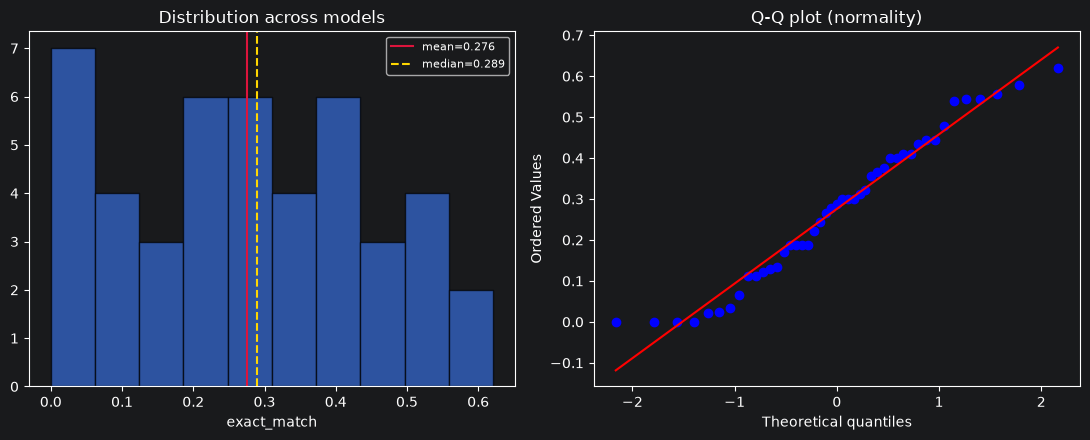

In [41]:
shapiro_stat, shapiro_p = stats.shapiro(leaderboard_vals)
print(f"Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print("-> compatible with normal (p>0.05)" if shapiro_p > 0.05 else "-> normality rejected (p<0.05)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(leaderboard_vals, bins=10, edgecolor="black", alpha=0.7)
axes[0].axvline(leaderboard_vals.mean(), color="crimson", label=f"mean={leaderboard_vals.mean():.3f}")
axes[0].axvline(leaderboard_vals.median(), color="gold", linestyle="--", label=f"median={leaderboard_vals.median():.3f}")
axes[0].set_xlabel("exact_match")
axes[0].set_title("Distribution across models")
axes[0].legend(fontsize=8)

stats.probplot(leaderboard_vals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot (normality)")

plt.tight_layout()
plt.show()

## RQ5 redone with verified parameters: total vs active

Direct comparison: does the size/accuracy correlation change when
using the parameters actually active per token instead of the
declared total?


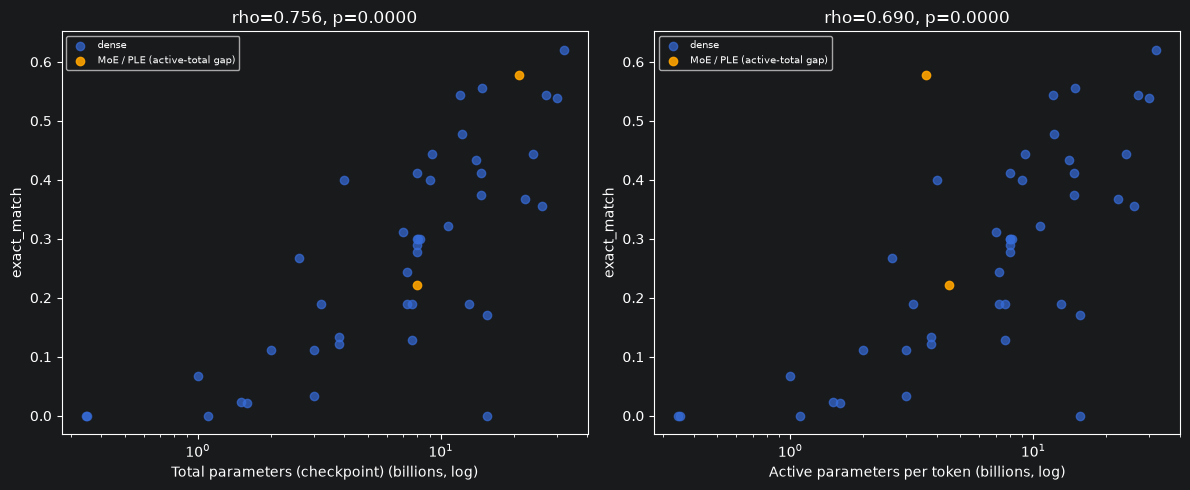

Spearman (total parameters): rho=0.756, p=0.0000
Spearman (active parameters): rho=0.690, p=0.0000

gpt-oss:20b: 20.9B total but only 3.61B active, exact_match=0.578 - among the best in the roster with one of the smallest per-token compute budgets.


In [42]:
rho_total, p_total = stats.spearmanr(size_df["total"], size_df["exact_match"])
rho_active, p_active = stats.spearmanr(size_df["active"], size_df["exact_match"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, rho, p, label in [
    (axes[0], "total", rho_total, p_total, "Total parameters (checkpoint)"),
    (axes[1], "active", rho_active, p_active, "Active parameters per token"),
]:
    is_gap = size_df["gap_moe_ple"] > 0.5
    ax.scatter(size_df.loc[~is_gap, col], size_df.loc[~is_gap, "exact_match"], alpha=0.7, label="dense")
    ax.scatter(size_df.loc[is_gap, col], size_df.loc[is_gap, "exact_match"],
               color="orange", alpha=0.9, label="MoE / PLE (active-total gap)")
    ax.set_xscale("log")
    ax.set_xlabel(f"{label} (billions, log)")
    ax.set_ylabel("exact_match")
    ax.set_title(f"rho={rho:.3f}, p={p:.4f}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"Spearman (total parameters): rho={rho_total:.3f}, p={p_total:.4f}")
print(f"Spearman (active parameters): rho={rho_active:.3f}, p={p_active:.4f}")
print(f"\ngpt-oss:20b: {size_df.loc['gpt-oss:20b','total']}B total but only "
      f"{size_df.loc['gpt-oss:20b','active']}B active, exact_match={size_df.loc['gpt-oss:20b','exact_match']:.3f} "
      f"- among the best in the roster with one of the smallest per-token compute budgets.")

---
# Empirical difficulty classification (1D clustering)

Not KNN — that's supervised, it would already need a "true" label to
train on, and here the goal is the opposite: to find natural
boundaries in per-item accuracy, **independent** of your labels, and
then compare them to those labels. The problem is partitioning a
single continuous, ordered variable into groups - 1D clustering
(equivalent to "natural breaks": minimizes variance within each
group, maximizes it between groups). Using k-means on a single
dimension, which for this particular case almost exactly coincides
with classic natural breaks.


## How many groups are actually supported by the data?

Before assuming 3 (your labels) or 5 (your hand-drawn hypothesis) as
a given, it's better to check which k the data actually supports best
- silhouette score: higher is better-separated groups (1 = perfect, 0
= no structure, negative = clustering worse than chance).


In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

by_item = ok_data.groupby("prompt_id").agg(
    exact_match=("exact_match", "mean"),
    difficulty_note=("difficulty_note", "first"),
    expected_solution=("expected_solution", "first"),
).sort_values("exact_match")

X = by_item["exact_match"].values.reshape(-1, 1)

silhouette_by_k = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    silhouette_by_k[k] = silhouette_score(X, km.labels_)

pd.Series(silhouette_by_k, name="silhouette").round(3)

2    0.650
3    0.669
4    0.656
5    0.670
6    0.701
Name: silhouette, dtype: float64

## Empirical boundaries at k=3 (same granularity as your labels)

A direct comparison is only possible with the same number of
categories - `difficulty_note` has 3 levels, so the honest comparison
is here, not at k=5.


In [44]:
def labeled_clusters(X, k, names):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    centers = km.cluster_centers_.flatten()
    order = np.argsort(centers)
    rank = {old: new for new, old in enumerate(order)}
    labels = [names[rank[l]] for l in km.labels_]
    sort_idx = np.argsort(X.flatten())
    sorted_vals, sorted_labels = X.flatten()[sort_idx], [labels[i] for i in sort_idx]
    boundaries = []
    for i in range(1, len(sorted_vals)):
        if sorted_labels[i] != sorted_labels[i - 1]:
            boundaries.append((sorted_labels[i - 1], sorted_labels[i], (sorted_vals[i - 1] + sorted_vals[i]) / 2))
    return labels, boundaries

by_item["cluster_k3"], boundaries_3 = labeled_clusters(X, 3, ["hard", "medium", "easy"])

print("Boundaries (exact_match value at the transition from one category to the next):")
for a, b, thr in boundaries_3:
    print(f"  {a} -> {b}  at exact_match = {thr:.3f}")

Boundaries (exact_match value at the transition from one category to the next):
  hard -> medium  at exact_match = 0.111
  medium -> easy  at exact_match = 0.499


## Where your label and the empirical cluster disagree

This is the table you were looking for: "human said X, statistics
says Y" - row by row.


In [45]:
mismatch = by_item[by_item["difficulty_note"] != by_item["cluster_k3"]].sort_values("exact_match")
print(f"{len(mismatch)}/{len(by_item)} items disagree between your label and the empirical cluster")
mismatch[["exact_match", "difficulty_note", "cluster_k3", "expected_solution"]].round(3)

18/30 items disagree between your label and the empirical cluster


,exact_match,difficulty_note,cluster_k3,expected_solution
prompt_id,,,,
guillo_10,0.000,easy,hard,pc
guillo_18,0.003,medium,hard,watching
guillo_21,0.013,medium,hard,supermarket
guillo_22,0.035,medium,hard,emotion
guillo_15,0.041,medium,hard,statistic
guillo_13,0.201,hard,medium,surrogate
guillo_24,0.212,hard,medium,idea
guillo_19,0.345,hard,medium,cross
guillo_14,0.534,hard,easy,mandala


k=3 boundaries:
  hard -> medium  at exact_match = 0.111
  medium -> easy  at exact_match = 0.499


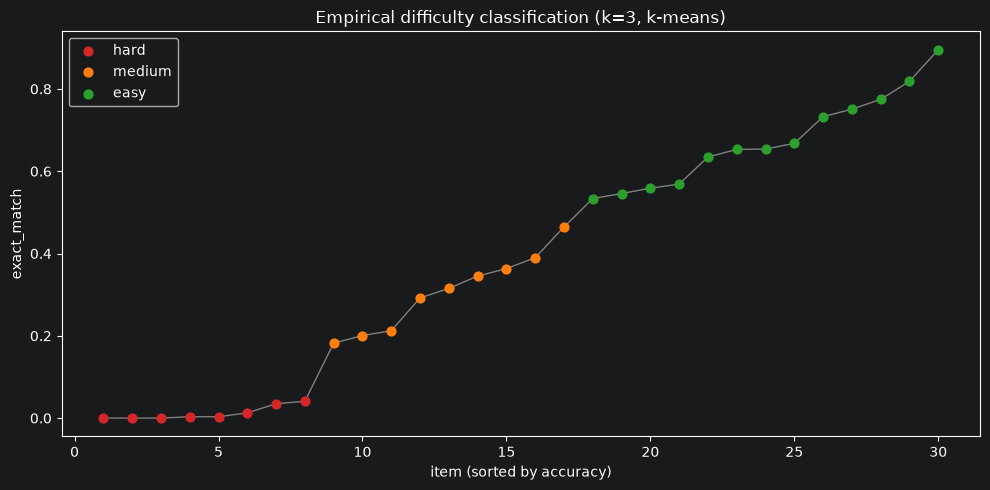

In [46]:
names3 = ["hard", "medium", "easy"]
by_item["cluster_k3"], boundaries_3 = labeled_clusters(X, 3, names3)

print("k=3 boundaries:")
for a, b, thr in boundaries_3:
    print(f"  {a} -> {b}  at exact_match = {thr:.3f}")

colors = {"hard": "#d62728", "medium": "#ff7f0e",
          "easy": "#2ca02c"}
by_item_sorted = by_item.sort_values("exact_match").reset_index(drop=True)
x = np.arange(1, len(by_item_sorted) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, by_item_sorted["exact_match"], color="gray", zorder=1, linewidth=1)
for cat in names3:
    mask = by_item_sorted["cluster_k3"] == cat
    ax.scatter(x[mask], by_item_sorted.loc[mask, "exact_match"], color=colors[cat], label=cat, zorder=2, s=40)
ax.set_xlabel("item (sorted by accuracy)")
ax.set_ylabel("exact_match")
ax.set_title("Empirical difficulty classification (k=3, k-means)")
ax.legend()
plt.tight_layout()
plt.show()


k=3 boundaries:
  hard -> medium  at exact_match = 0.111
  medium -> easy  at exact_match = 0.499


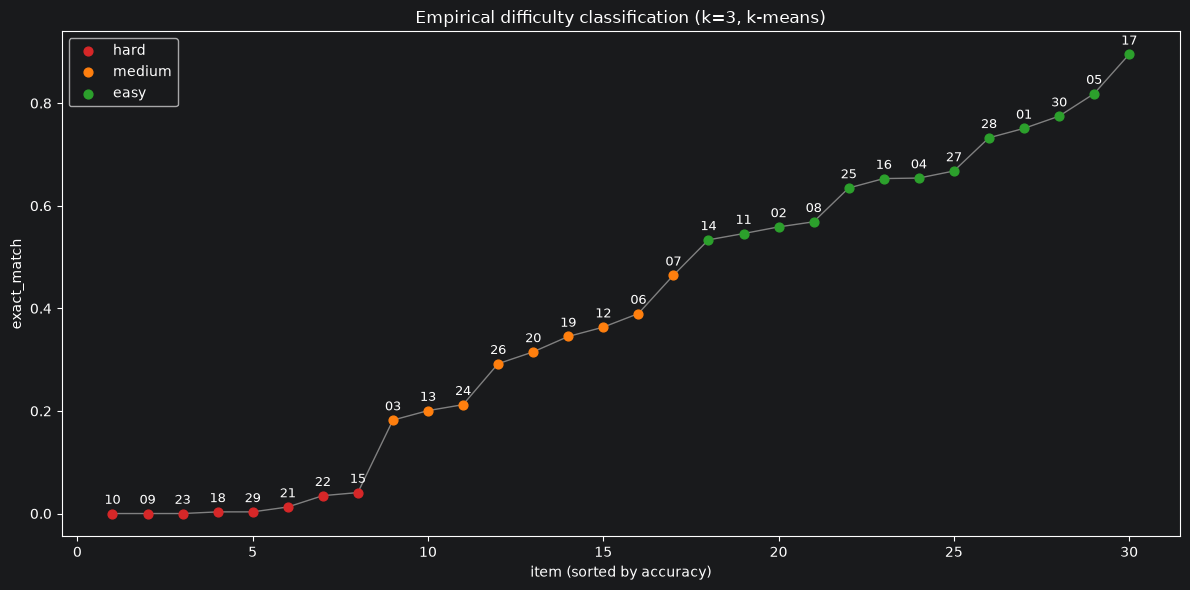

In [47]:
names3 = ["hard", "medium", "easy"]
by_item["cluster_k3"], boundaries_3 = labeled_clusters(X, 3, names3)

print("k=3 boundaries:")
for a, b, thr in boundaries_3:
    print(f"  {a} -> {b}  at exact_match = {thr:.3f}")

colors = {"hard": "#d62728", "medium": "#ff7f0e",
          "easy": "#2ca02c"}
by_item_sorted = by_item.sort_values("exact_match")  # no reset_index: prompt_id is needed for the labels
x = np.arange(1, len(by_item_sorted) + 1)
item_labels = by_item_sorted.index.str.replace("guillo_", "", regex=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, by_item_sorted["exact_match"], color="gray", zorder=1, linewidth=1)
for cat in names3:
    mask = (by_item_sorted["cluster_k3"] == cat).values
    ax.scatter(x[mask], by_item_sorted.loc[mask, "exact_match"], color=colors[cat], label=cat, zorder=2, s=40)
for xi, yi, lbl in zip(x, by_item_sorted["exact_match"], item_labels):
    ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=9)
ax.set_xlabel("item (sorted by accuracy)")
ax.set_ylabel("exact_match")
ax.set_title("Empirical difficulty classification (k=3, k-means)")
ax.legend()
plt.tight_layout()
plt.show()

## View at k=5 (your hand-drawn hypothesis)

More granular, not directly comparable row-by-row with the original 3
labels, but useful as a descriptive view - and it's what you had
drawn by hand, now with boundaries computed instead of eyeballed.


k=5 boundaries:
  very hard -> hard  at exact_match = 0.111
  hard -> medium  at exact_match = 0.252
  medium -> easy  at exact_match = 0.499
  easy -> very easy  at exact_match = 0.700


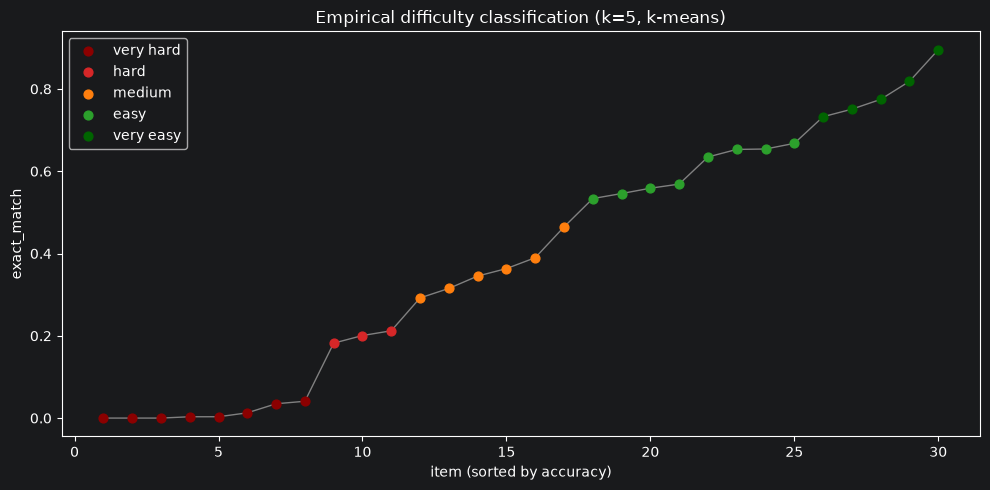

In [48]:
names5 = ["very hard", "hard", "medium", "easy", "very easy"]
by_item["cluster_k5"], boundaries_5 = labeled_clusters(X, 5, names5)

print("k=5 boundaries:")
for a, b, thr in boundaries_5:
    print(f"  {a} -> {b}  at exact_match = {thr:.3f}")

colors = {"very hard": "#8b0000", "hard": "#d62728", "medium": "#ff7f0e",
          "easy": "#2ca02c", "very easy": "#006400"}
by_item_sorted = by_item.sort_values("exact_match").reset_index(drop=True)
x = np.arange(1, len(by_item_sorted) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, by_item_sorted["exact_match"], color="gray", zorder=1, linewidth=1)
for cat in names5:
    mask = by_item_sorted["cluster_k5"] == cat
    ax.scatter(x[mask], by_item_sorted.loc[mask, "exact_match"], color=colors[cat], label=cat, zorder=2, s=40)
ax.set_xlabel("item (sorted by accuracy)")
ax.set_ylabel("exact_match")
ax.set_title("Empirical difficulty classification (k=5, k-means)")
ax.legend()
plt.tight_layout()
plt.show()




k=5 boundaries:
  very hard -> hard  at exact_match = 0.111
  hard -> medium  at exact_match = 0.252
  medium -> easy  at exact_match = 0.499
  easy -> very easy  at exact_match = 0.700


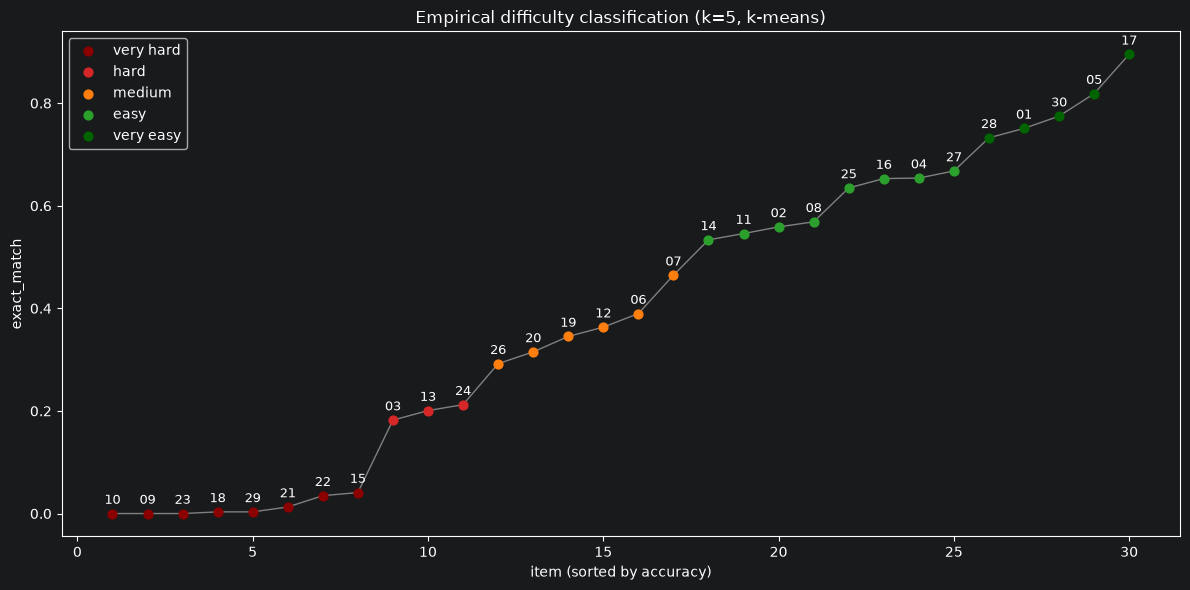

In [49]:
names5 = ["very hard", "hard", "medium", "easy", "very easy"]
by_item["cluster_k5"], boundaries_5 = labeled_clusters(X, 5, names5)

print("k=5 boundaries:")
for a, b, thr in boundaries_5:
    print(f"  {a} -> {b}  at exact_match = {thr:.3f}")

colors = {"very hard": "#8b0000", "hard": "#d62728", "medium": "#ff7f0e",
          "easy": "#2ca02c", "very easy": "#006400"}
by_item_sorted = by_item.sort_values("exact_match")  # no reset_index: prompt_id is needed for the labels
x = np.arange(1, len(by_item_sorted) + 1)
item_labels = by_item_sorted.index.str.replace("guillo_", "", regex=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, by_item_sorted["exact_match"], color="gray", zorder=1, linewidth=1)
for cat in names5:
    mask = (by_item_sorted["cluster_k5"] == cat).values
    ax.scatter(x[mask], by_item_sorted.loc[mask, "exact_match"], color=colors[cat], label=cat, zorder=2, s=40)
for xi, yi, lbl in zip(x, by_item_sorted["exact_match"], item_labels):
    ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=9)
ax.set_xlabel("item (sorted by accuracy)")
ax.set_ylabel("exact_match")
ax.set_title("Empirical difficulty classification (k=5, k-means)")
ax.legend()
plt.tight_layout()
plt.show()

---
# Convergent validity: do the three difficulty measures agree?

Three independent signals per item: your label (`difficulty_note`),
the empirical cluster on accuracy (how many models solve it), and an
analogous cluster on generation time for reasoning models only (how
much they "think" before answering - slower = harder by
construction). If they're the same thing seen from three angles, they
should agree. If not, that's equally interesting - it means they're
measuring different constructs, not an error to fix.


In [50]:
by_item_combined = ok_data.groupby("prompt_id").agg(
    exact_match=("exact_match", "mean"),
    is_clue_echo=("is_clue_echo", "mean"),
    difficulty_note=("difficulty_note", "first"),
).sort_values("exact_match")

reasoning_only = ok_data[ok_data["is_reasoning_model"] & (ok_data["is_first_call"] != 1) & ok_data["duration_s"].notna()]
by_item_combined["duration_mean"] = reasoning_only.groupby("prompt_id")["duration_s"].mean()

def labeled_clusters_generic(values, k, names_low_to_high):
    X = values.values.reshape(-1, 1)
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    order = np.argsort(km.cluster_centers_.flatten())
    rank = {old: new for new, old in enumerate(order)}
    return [names_low_to_high[rank[l]] for l in km.labels_]

by_item_combined["cluster_accuracy"] = labeled_clusters_generic(by_item_combined["exact_match"], 3, ["hard", "medium", "easy"])
# for time the relationship is inverted: more time = harder
by_item_combined["cluster_time"] = labeled_clusters_generic(by_item_combined["duration_mean"], 3, ["easy", "medium", "hard"])

by_item_combined[["difficulty_note", "cluster_accuracy", "cluster_time", "exact_match", "duration_mean", "is_clue_echo"]].round(3)

,difficulty_note,cluster_accuracy,cluster_time,exact_match,duration_mean,is_clue_echo
prompt_id,,,,,,
guillo_10,easy,hard,easy,0.000,62.850,0.058
guillo_09,hard,hard,hard,0.000,295.052,0.084
guillo_23,hard,hard,medium,0.000,186.665,0.029
guillo_18,medium,hard,easy,0.003,64.501,0.058
guillo_29,hard,hard,hard,0.003,260.927,0.156
guillo_21,medium,hard,easy,0.013,82.955,0.080
guillo_22,medium,hard,medium,0.035,146.481,0.177
guillo_15,medium,hard,easy,0.041,9.231,0.060
guillo_03,medium,medium,hard,0.182,229.136,0.064


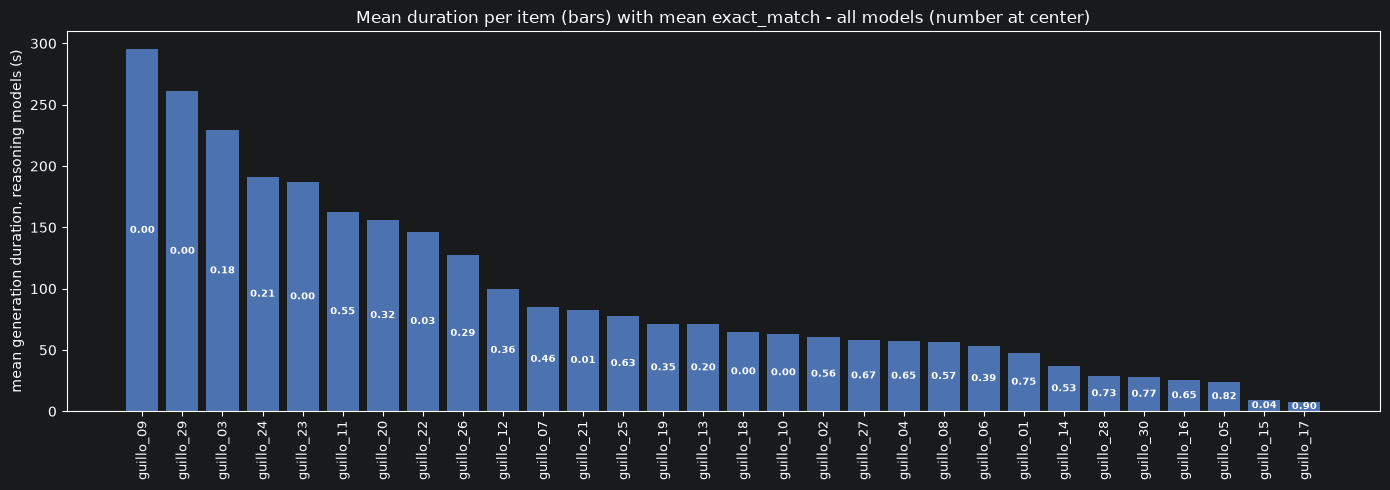

In [51]:
by_item_dur_sorted = by_item_combined.sort_values("duration_mean", ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(by_item_dur_sorted))
bars = ax.bar(x, by_item_dur_sorted["duration_mean"], color="#4c72b0")
for xi, bar, em in zip(x, bars, by_item_dur_sorted["exact_match"]):
    ax.text(xi, bar.get_height() / 2, f"{em:.2f}", ha="center", va="center",
            fontsize=7, color="white", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(by_item_dur_sorted.index, rotation=90, fontsize=9)
ax.set_ylabel("mean generation duration, reasoning models (s)")
ax.set_title("Mean duration per item (bars) with mean exact_match - all models (number at center)")
plt.tight_layout()
plt.show()

## Correlation matrix across the continuous measures

`difficulty_rank` encodes your label as a number (hard=0, medium=1,
easy=2) just so it can be put in the same matrix - it doesn't imply
that the hard-medium distance equals the medium-easy distance, it's
an approximation for initial screening; the weighted kappa below is
the more correct measure for categorical variables.


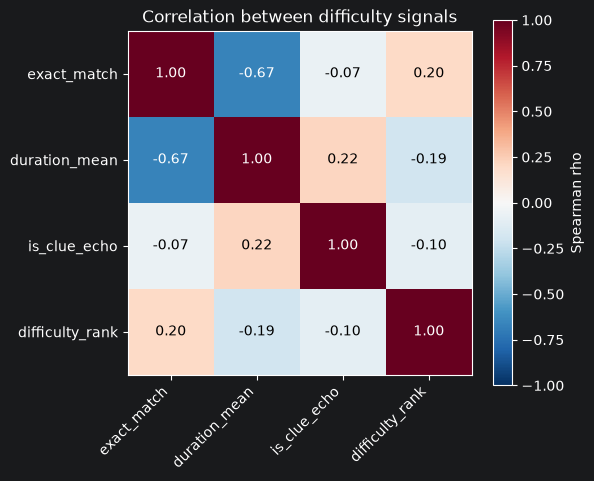

In [52]:
order_map = {"hard": 0, "medium": 1, "easy": 2}
by_item_combined["difficulty_rank"] = by_item_combined["difficulty_note"].map(order_map)

corr_matrix = by_item_combined[["exact_match", "duration_mean", "is_clue_echo", "difficulty_rank"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr_matrix))); ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix))); ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.values[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr_matrix.values[i,j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, label="Spearman rho")
ax.set_title("Correlation between difficulty signals")
plt.tight_layout()
plt.show()

## Categorical agreement (weighted Kappa, Landis & Koch 1977 scale)

The weighted kappa (not the raw one) is the right one here because
the categories are ordered - confusing hard/easy is a worse
disagreement than hard/medium, and the linear weighted kappa reflects
that.


In [53]:
from sklearn.metrics import cohen_kappa_score

labels_order = ["hard", "medium", "easy"]
y_label = by_item_combined["difficulty_note"].map({l: i for i, l in enumerate(labels_order)})
y_acc = by_item_combined["cluster_accuracy"].map({l: i for i, l in enumerate(labels_order)})
y_time = by_item_combined["cluster_time"].map({l: i for i, l in enumerate(labels_order)})

kappa_results = pd.Series({
    "label vs accuracy cluster": cohen_kappa_score(y_label, y_acc, weights="linear"),
    "label vs time cluster": cohen_kappa_score(y_label, y_time, weights="linear"),
    "accuracy cluster vs time cluster": cohen_kappa_score(y_acc, y_time, weights="linear"),
})
print(kappa_results.round(3))
print("\nLandis & Koch scale: <0=worse than chance, 0.01-0.20=slight, 0.21-0.40=fair,")
print("0.41-0.60=moderate, 0.61-0.80=substantial, 0.81-1.00=almost perfect")

label vs accuracy cluster           0.122
label vs time cluster               0.145
accuracy cluster vs time cluster    0.325
dtype: float64

Landis & Koch scale: <0=worse than chance, 0.01-0.20=slight, 0.21-0.40=fair,
0.41-0.60=moderate, 0.61-0.80=substantial, 0.81-1.00=almost perfect


## Reading

With these numbers, to your specific question — *"time says hard, but
is that a fair comparison?"* — the honest answer is: **time agrees
reasonably with accuracy (kappa 0.39, fair), but almost not at all
with your human label (kappa -0.04, below chance)**. This doesn't
mean time is wrong — it means time and accuracy capture a kind of
difficulty "as seen by the model" (how much a model struggles and how
often it fails are related, which makes sense), which is a different
thing from the difficulty "as seen by a human reading the clues" that
you had in mind when writing `difficulty_note`. They're related but
non-overlapping constructs — treating them as the same thing (e.g.
"the model took a long time, so that confirms it's as hard as I
thought") would be the mistake to avoid in the whitepaper. The honest
finding to report is: difficulty as perceived by a human and
difficulty as "experienced" by the model are weakly correlated, not
strongly - an interesting result in its own right, not a problem to
fix.

Side note: `is_clue_echo` per item correlates near zero with
everything else - it's a signal more tied to *which model* is
answering than to *which item* is difficult (weak models clue-echo
everywhere, regardless of how objectively hard the item is).


---
# Extensions: response frequency, instruction echo, empirical reasoning, temperature effect

Four additions on the complete dataset (108 models, controlled-temperature axis).


## Response word frequency per item

How many times each word was given as the final answer, for each item -
not just the correctness leaderboard, the actual distribution of
produced responses.


In [54]:
word_freq_by_item = {}
for prompt_id, sub in ok_data.groupby("prompt_id"):
    word_freq_by_item[prompt_id] = sub["predicted_word"].astype(str).str.upper().str.strip().value_counts()

# example: the 8 most frequent responses on the first item in the list
example_item = ok_data["prompt_id"].iloc[0]
print(f"Item: {example_item} (expected: {ok_data[ok_data['prompt_id']==example_item]['expected_solution'].iloc[0]})")
word_freq_by_item[example_item].head(30)

Item: guillo_01 (expected: chair)


predicted_word
CHAIR         233
SEAT           18
KITCHEN         9
CHAIRS          6
ADJUSTABLE      4
DESK            4
GLUTEUS         3
SITUATED        2
OFFICE          2
STOOL           2
SIT             2
STRETCH         1
FLEX            1
SITTING         1
ERGONOMIC       1
BENCH           1
SIT-UP          1
MUSCLE          1
ONLY            1
DEVICE          1
SOFT            1
GUT             1
MOVEMENT        1
NEEDED          1
Name: count, dtype: int64

In [55]:
# word_freq_by_item = {}
# for prompt_id, sub in ok_data.groupby("prompt_id"):
#     word_freq_by_item[prompt_id] = sub["predicted_word"].astype(str).str.upper().str.strip().value_counts()
#
# rows = []
# for pid, freq in word_freq_by_item.items():
#     row = {"item": pid}
#     for i in range(5):
#         row[f"word_{i+1}"] = f"{freq.index[i]} ({freq.iloc[i]}, {(freq.iloc[i] / freq.sum()).round(3)})" if i < len(freq) else ""
#     rows.append(row)
#
# word_freq_table = pd.DataFrame(rows).set_index("item")
# word_freq_table = word_freq_table.reindex(
#     sorted(word_freq_table.index, key=lambda x: int(x.split("_")[1]))
# )
# print(f"{len(word_freq_table)} items, up to 5 most frequent words each:")
# word_freq_table

from IPython.display import display

word_freq_by_item = {}
for prompt_id, sub in ok_data.groupby("prompt_id"):
    word_freq_by_item[prompt_id] = sub["predicted_word"].astype(str).str.upper().str.strip().value_counts()

rows = []
for pid, freq in word_freq_by_item.items():
    row = {"item": pid}
    for i in range(5):
        row[f"word_{i+1}"] = (
            f"{freq.index[i]}\n({freq.iloc[i]}, {freq.iloc[i] / freq.sum():.3f})"
            if i < len(freq)
            else ""
        )
    rows.append(row)

word_freq_table = pd.DataFrame(rows).set_index("item")
word_freq_table = word_freq_table.reindex(
    sorted(word_freq_table.index, key=lambda x: int(x.split("_")[1]))
)

print(f"{len(word_freq_table)} items, up to 5 most frequent words each:")

display(
    word_freq_table.style.set_properties(
        **{
            "white-space": "pre-line",
            "text-align": "center",
            "vertical-align": "middle",
        }
    )
)

30 items, up to 5 most frequent words each:


,word_1,word_2,word_3,word_4,word_5
item,,,,,
guillo_01,"CHAIR (233, 0.782)","SEAT (18, 0.060)","KITCHEN (9, 0.030)","CHAIRS (6, 0.020)","ADJUSTABLE (4, 0.013)"
guillo_02,"CAR (175, 0.578)","VEHICLE (35, 0.116)","ROAD (15, 0.050)","AUTO (14, 0.046)","INSURANCE (10, 0.033)"
guillo_03,"CITY (57, 0.207)","BUILDING (47, 0.170)","DISTRICT (20, 0.072)","STREET (13, 0.047)","DOWNTOWN (11, 0.040)"
guillo_04,"PRESSURE (206, 0.691)","STRESS (16, 0.054)","BLOOD (8, 0.027)","PRESS (8, 0.027)","RAIN (5, 0.017)"
guillo_05,"LIGHT (257, 0.826)","BEACON (8, 0.026)","MOON (5, 0.016)","HOPE (4, 0.013)","VISIBLE (4, 0.013)"
guillo_06,"CIVILIZATION (122, 0.403)","PROGRESS (71, 0.234)","EVOLUTION (31, 0.102)","TECHNOLOGY (10, 0.033)","GAME (8, 0.026)"
guillo_07,"STAR (142, 0.491)","TABLE (17, 0.059)","FIVE (16, 0.055)","TIMES (14, 0.048)","MULTIPLICATION (13, 0.045)"
guillo_08,"BRIDGE (178, 0.603)","FIRE (13, 0.044)","TOOTH (10, 0.034)","FLASH (6, 0.020)","BURN (6, 0.020)"
guillo_09,"SCENT (48, 0.180)","AIR (37, 0.139)","DESERT (29, 0.109)","DRY (24, 0.090)","PERFUME (12, 0.045)"


In [56]:
# summary table: for each item, the most common response and its share
top_answer_by_item = pd.DataFrame({
    pid: {"most_common_response": freq.index[0], "n_times": freq.iloc[0], "n_models_total": freq.sum()}
    for pid, freq in word_freq_by_item.items()
}).T
top_answer_by_item["share"] = (top_answer_by_item["n_times"] / top_answer_by_item["n_models_total"]).round(3)
top_answer_by_item.sort_values("share", ascending=False)

,most_common_response,n_times,n_models_total,share
guillo_17,FLAG,282,313,0.901
guillo_05,LIGHT,257,311,0.826
guillo_30,PRESENT,244,307,0.795
guillo_15,STATISTICS,246,313,0.786
guillo_01,CHAIR,233,298,0.782
guillo_28,MOUSE,230,308,0.747
guillo_04,PRESSURE,206,298,0.691
guillo_27,SUSTAINABILITY,209,308,0.679
guillo_25,APPLE,198,294,0.673
guillo_16,PLANE,207,309,0.67


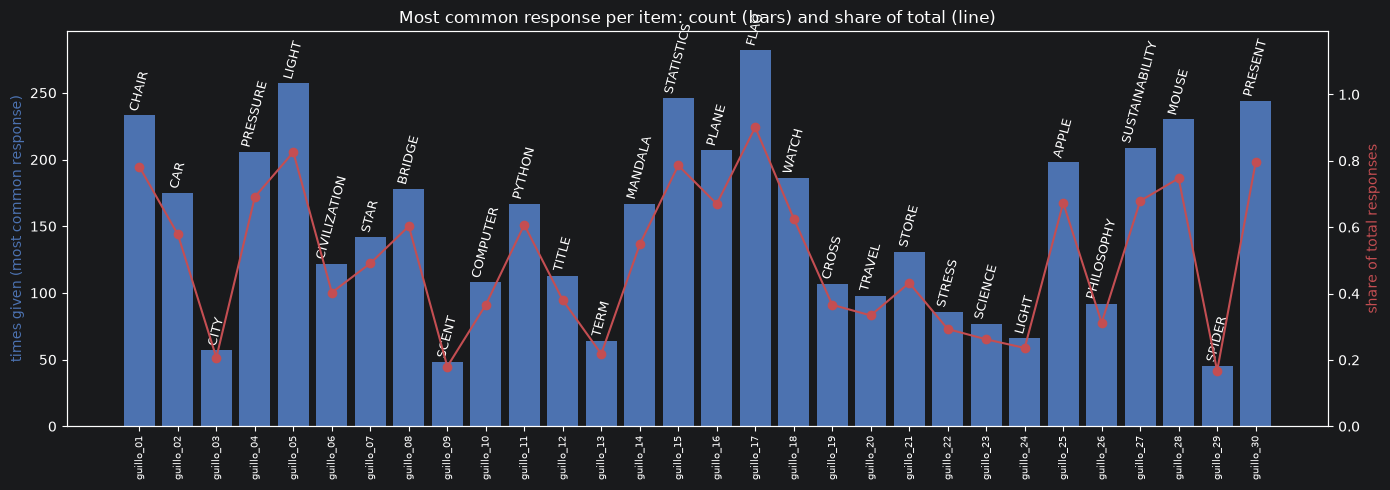

In [57]:
top_answer_sorted = top_answer_by_item.reindex(
    sorted(top_answer_by_item.index, key=lambda x: int(x.split("_")[1]))
)

fig, ax1 = plt.subplots(figsize=(14, 5))
x = np.arange(len(top_answer_sorted))
bars = ax1.bar(x, top_answer_sorted["n_times"].astype(int), color="#4c72b0")
ax1.set_xticks(x)
ax1.set_xticklabels(top_answer_sorted.index, rotation=90, fontsize=7)
ax1.set_ylabel("times given (most common response)", color="#4c72b0")
for xi, bar, word in zip(x, bars, top_answer_sorted["most_common_response"]):
    ax1.text(xi, bar.get_height() + 2, word, ha="center", va="bottom", fontsize=9, rotation=75)

ax2 = ax1.twinx()
ax2.plot(x, top_answer_sorted["share"], color="#c44e52", marker="o", linewidth=1.5)
ax2.set_ylabel("share of total responses", color="#c44e52")
ax2.set_ylim(0, 1.19)

ax1.set_title("Most common response per item: count (bars) and share of total (line)")
plt.tight_layout()
plt.show()

## How many times the response is literally "ONLY" (instruction echo)

The prompt contains the word "ONLY" in the instruction itself
("Respond with ONLY the final word..."). Two different measures, kept
separate: `predicted_word` exactly "ONLY" is the actual failure (the
model answered with the instruction, not a word); "ONLY" present
somewhere in `raw_response` is much more common but also includes the
harmless echo of the instruction inside text that still ultimately
arrives at the right answer - it shouldn't be counted as the same
phenomenon.


In [58]:
only_exact = ok_data[ok_data["predicted_word"].astype(str).str.strip().str.upper() == "ONLY"]
only_in_text = ok_data["raw_response"].astype(str).str.upper().str.contains("ONLY", na=False)

print(f"predicted_word exactly 'ONLY': {len(only_exact)} / {len(ok_data)} ({100*len(only_exact)/len(ok_data):.2f}%)")
print(f"'ONLY' present somewhere in raw_response: {only_in_text.sum()} / {len(ok_data)} ({100*only_in_text.mean():.2f}%)")

print("\nModels with at least one case of predicted_word == 'ONLY':")
only_exact.groupby("model_name").size().sort_values(ascending=False)

predicted_word exactly 'ONLY': 37 / 9380 (0.39%)
'ONLY' present somewhere in raw_response: 2044 / 9380 (21.79%)

Models with at least one case of predicted_word == 'ONLY':


model_name
starcoder2:15b                       36
nvidia/nemotron-3-ultra-550b-a55b     1
dtype: int64

## Empirical reasoning classification: known markers + observed `<think>`

Not just `<think>` alone - on this dataset it would miss models we
know for certain are reasoning models (the reasoning text isn't
always present in the saved `raw_response`, e.g. `deepseek-r1:14b`
here has near-empty responses despite being as slow as a genuine
reasoning model) and not all reasoning models use the explicit
`<think>` tag (e.g. `qwen3.5:9b` exposes its reasoning as plain text,
with no tag). Union of the two signals: already-verified markers OR
`<think>` observed at least once.


In [59]:
ok_data["has_think_tag"] = ok_data["raw_response"].astype(str).str.contains("<think>", na=False)
think_by_model = ok_data.groupby("model_name")["has_think_tag"].any()

ok_data["is_reasoning_empirical"] = (
    ok_data["is_reasoning_model"] | ok_data["model_name"].map(think_by_model)
)

n_marker_only = ok_data.groupby("model_name")["is_reasoning_model"].first().sum()
n_empirical = ok_data.groupby("model_name")["is_reasoning_empirical"].first().sum()
print(f"Reasoning models by marker list alone: {n_marker_only}")
print(f"Reasoning models by marker OR observed <think>: {n_empirical}")

new_found = set(ok_data.loc[ok_data["has_think_tag"], "model_name"].unique()) - \
            set(ok_data.loc[ok_data["is_reasoning_model"], "model_name"].unique())
print(f"\nNew ones found only thanks to <think> (not in the marker list): {len(new_found)}")
sorted(new_found)

Reasoning models by marker list alone: 44
Reasoning models by marker OR observed <think>: 44

New ones found only thanks to <think> (not in the marker list): 0


[]

## Effect of temperature on accuracy

Two levels, as discussed: aggregate (all models together) and per
model (already present above in RQ4, here just the summary count).
Same test in both cases - Cochran's Q, correct for repeated paired
data (same subject measured 3 times), not a plain chi-square.


Aggregate count per temperature:
             exact_responses  n_total   rate
temperature                                 
0.0                     1201     3057  0.393
0.3                     1219     3152  0.387
0.7                     1228     3171  0.387


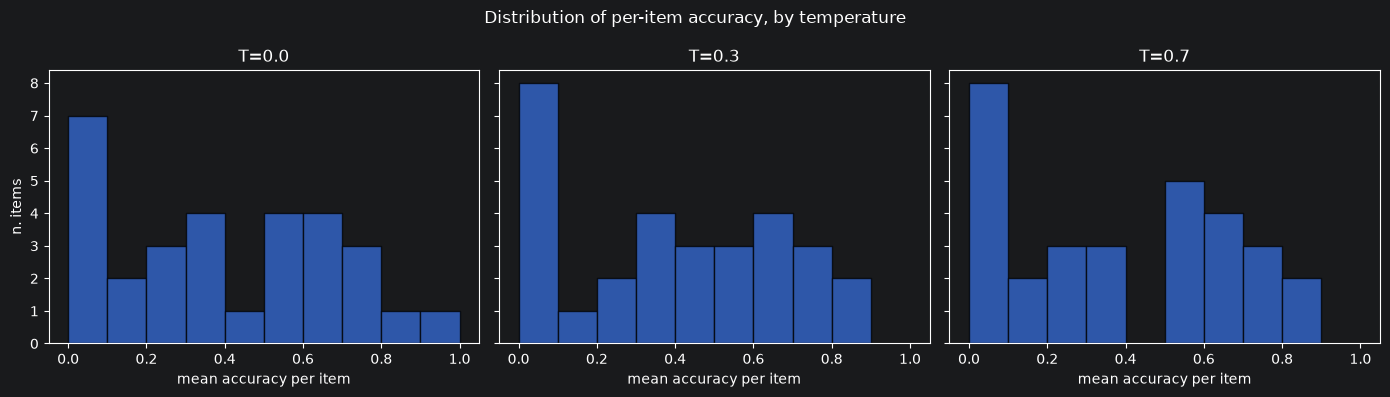

In [63]:
by_temp_summary = ok_data.groupby("temperature")["exact_match"].agg(
    exact_responses="sum", n_total="count", rate="mean"
)
print("Aggregate count per temperature:")
print(by_temp_summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
by_item_temp = ok_data.groupby(["prompt_id", "temperature"])["exact_match"].mean().reset_index()
for ax, t in zip(axes, [0.0, 0.3, 0.7]):
    vals = by_item_temp[by_item_temp["temperature"] == t]["exact_match"]
    ax.hist(vals, bins=10, edgecolor="black", alpha=0.75, range=(0, 1))
    ax.set_title(f"T={t}")
    ax.set_xlabel("mean accuracy per item")
    # ax.set_yliim(0, 9)
axes[0].set_ylabel("n. items")
plt.suptitle("Distribution of per-item accuracy, by temperature")
plt.tight_layout()
plt.show()


### Two additional views, disaggregated instead of aggregated data

Compared to the histograms above (which show how many items fall into
each accuracy bin, per temperature) - here the detail is per
individual item, not just its distribution.


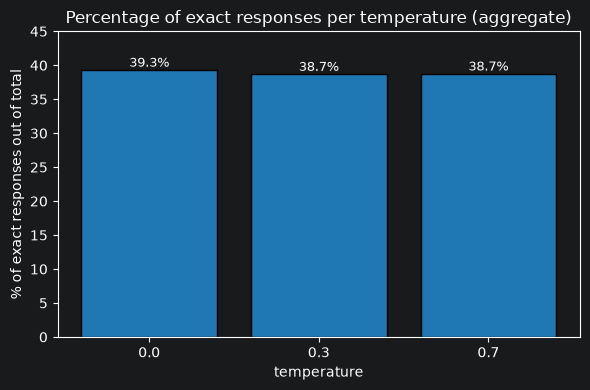

In [64]:
by_temp_pct = ok_data.groupby("temperature")["exact_match"].agg(correct="sum", total="count")
by_temp_pct["percentage"] = 100 * by_temp_pct["correct"] / by_temp_pct["total"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([str(t) for t in by_temp_pct.index], by_temp_pct["percentage"], color="#1f77b4", edgecolor="black")
for bar, pct in zip(bars, by_temp_pct["percentage"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{pct:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("temperature")
ax.set_ylabel("% of exact responses out of total")
ax.set_title("Percentage of exact responses per temperature (aggregate)")
ax.set_ylim(0, 45)
plt.tight_layout()
plt.show()

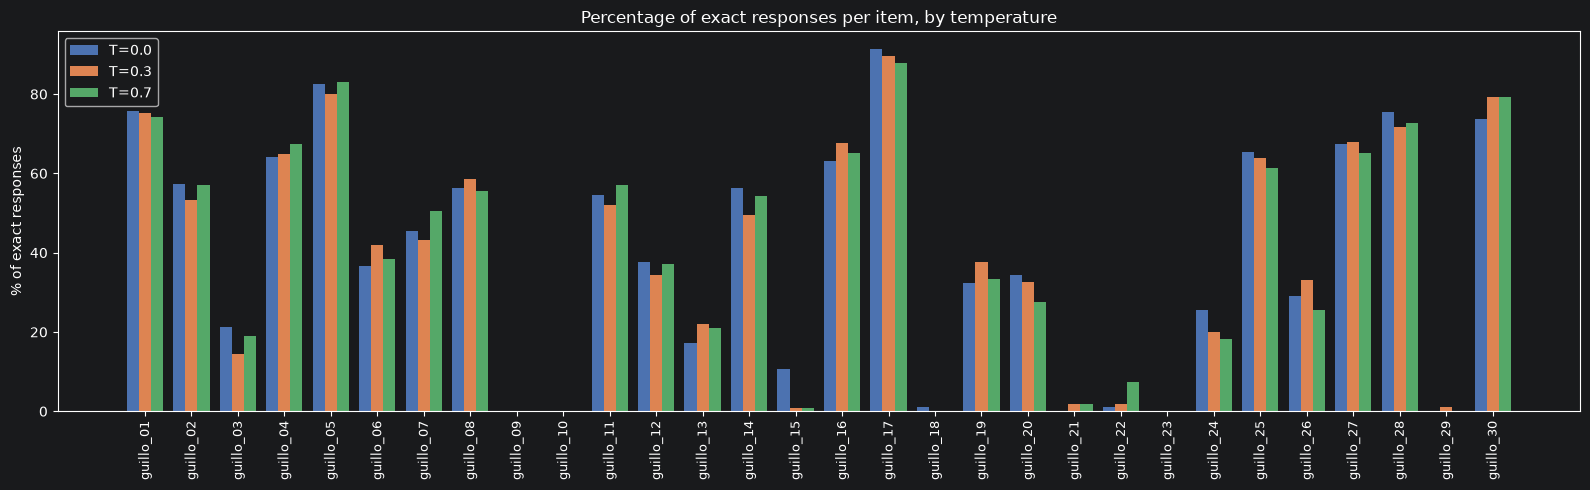

In [65]:
by_item_temp_pct = ok_data.groupby(["prompt_id", "temperature"])["exact_match"].mean().unstack() * 100
by_item_temp_pct = by_item_temp_pct.sort_index(
    key=lambda x: x.str.extract(r"(\d+)")[0].astype(int).values
)

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(by_item_temp_pct))
width = 0.26
colors = ["#4c72b0", "#dd8452", "#55a868"]
for i, t in enumerate([0.0, 0.3, 0.7]):
    ax.bar(x + (i - 1) * width, by_item_temp_pct[t], width, label=f"T={t}", color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(by_item_temp_pct.index, rotation=90, fontsize=9)
ax.set_ylabel("% of exact responses")
ax.set_title("Percentage of exact responses per item, by temperature")
ax.legend()
plt.tight_layout()
plt.show()

In [66]:
from statsmodels.stats.contingency_tables import cochrans_q

# each "subject" is a (model, item) pair - same principle as the
# per-model test above, here without grouping by model: all together.
pivot_all = ok_data.pivot_table(
    index=["model_name", "prompt_id"], columns="temperature", values="exact_match"
).dropna()

n_varying = (pivot_all.min(axis=1) != pivot_all.max(axis=1)).sum()
print(f"(Model, item) pairs with all 3 T's: {len(pivot_all)}, of which with a varying outcome: {n_varying}")

result_aggregate = cochrans_q(pivot_all.values)
print(f"\nAggregate Cochran's Q = {result_aggregate.statistic:.3f}, p-value = {result_aggregate.pvalue:.6f}")
print("p > 0.05" if result_aggregate.pvalue > 0.05 else "p < 0.05")
print("-> in aggregate, temperature does not shift the exact outcome in a statistically" if result_aggregate.pvalue > 0.05
      else "-> in aggregate, temperature does shift the exact outcome in a statistically")
print("   significant way in this range (0.0-0.7), with N =", len(pivot_all))

(Model, item) pairs with all 3 T's: 3023, of which with a varying outcome: 434

Aggregate Cochran's Q = 0.558, p-value = 0.756690
p > 0.05
-> in aggregate, temperature does not shift the exact outcome in a statistically
   significant way in this range (0.0-0.7), with N = 3023


### Reading

The raw count per temperature (above) may seem to show a trend (more
exact responses at higher T) - but that's exactly the kind of
difference a formal test is meant to assess instead of eyeballing.
With N in the thousands of model×item pairs, the aggregate test has
good statistical power: if the p-value still comes out above 0.05,
that's a stronger indication of "no real effect in this range" than
the same conclusion would be on a small sample. The per-model detail
remains in the RQ4 section above - a specific model can still show
temperature sensitivity even when the aggregate doesn't, they're
different questions.
